# Step 1: Import Dataset

In [55]:
# Library to import data
import pandas as pd

Ibrahim Data

In [ ]:
# Importing Ibrahim Dataset
ibrahim_data = pd.read_csv('./Dataset/new ibrahim karatas/kaggle_fake_train/kaggle_fake_train.csv')

Jair Data

In [ ]:
# Importing Jair Dataset
Jair_data_1 = pd.read_csv('./Dataset/new Jair Ribeiro/True.csv')
Jair_data_2 = pd.read_csv('./Dataset/new Jair Ribeiro/Fake.csv')

In [58]:
Jair_data_1['label'] = 1
Jair_data_2['label'] = 0

In [59]:
# Merge data1, data2
Jair_data = pd.concat([Jair_data_1, Jair_data_2])

Rahul Data

In [ ]:
# Importing Rahul Dataset
Rahul_data = pd.read_csv('./Dataset/new Rahul Thorat/fakenews.csv')

Elvin Data

In [ ]:
# Importing Elvin Dataset
elvin_data_1 = pd.read_csv('./Dataset/ELVIN AGHAMMADZADA/Y_Constraint_Train.csv')
elvin_data_2 = pd.read_csv('./Dataset/ELVIN AGHAMMADZADA/Y_Constraint_Val.csv')
elvin_data_3 = pd.read_csv('./Dataset/ELVIN AGHAMMADZADA/Y_english_test_with_labels.csv')

In [62]:
# Merge data1, data2, data3
elvin_data = pd.concat([elvin_data_1, elvin_data_2, elvin_data_3])

Jruvika Data

In [ ]:
# Importing Jruvika Dataset
jruvika_data = pd.read_csv('./Dataset/JRUVIKA/data.csv')

Saurabh Data

In [ ]:
# Importing Saurabh Dataset
saurabh_data = pd.read_csv('./Dataset/SAURABH SHAHANE/WELFake_Dataset.csv')

Challenge Data

In [ ]:
# Importing Challenge Dataset
challenge_data_1 = pd.read_csv('./Dataset/Challenge/train.csv')
challenge_data_2 = pd.read_csv('./Dataset/Challenge/test.csv')
challenge_data_3 = pd.read_csv('./Dataset/Challenge/submit.csv')

In [66]:
# Merge data with its labelling
challenge_data_4 = pd.merge(challenge_data_2, challenge_data_3, on='id', how='left')

In [67]:
# Merge data1, data4
challenge_data = pd.concat([challenge_data_1, challenge_data_4])

IEEE Data

In [ ]:
# Importing IEEE Dataset
ieee_data_1 = pd.read_csv('./Dataset/IEEE-FNID-dataset/fake news detection(FakeNewsNet)/fnn_dev.csv')
ieee_data_2 = pd.read_csv('./Dataset/IEEE-FNID-dataset/fake news detection(FakeNewsNet)/fnn_test.csv')
ieee_data_3 = pd.read_csv('./Dataset/IEEE-FNID-dataset/fake news detection(FakeNewsNet)/fnn_train.csv')

In [69]:
# Merge data1, data2, data3, data4, data5, data6
ieee_data = pd.concat([ieee_data_1, ieee_data_2, ieee_data_3])

# Step 2: Data Cleaning and Merging

Handle Missing Values

In [70]:
# Checking Missing Values in each dataset

missing_values_ibrahim = ibrahim_data.isnull().sum()      # id 0; title 558; author 1957; text 39; label 0
missing_values_jair = Jair_data.isnull().sum()            # title 0; text 0; subject 0; date 0; label 0
missing_values_rahul = Rahul_data.isnull().sum()          # text 0; label 0
missing_values_elvin = elvin_data.isnull().sum()          # id 0;                                             tweet 0;  label 0;
missing_values_jruvika = jruvika_data.isnull().sum()      #               URLs 0;   Headline 0;               Body 21;  Label 0;
missing_values_saurabh = saurabh_data.isnull().sum()      # Unnamed: 0 0;           title 558;                text 39;  label 0;
missing_values_challenge = challenge_data.isnull().sum()  # id 0;                   title 680;  author 2460;  text 46;  label 0;
missing_values_ieee = ieee_data.isnull().sum()            # id 0; date 0; speaker 0; statement 0; sources 0; paragraph 0; fullText 0; label 0;

In [71]:
# Remove rows with missing values in the 'text' column
ibrahim_data = ibrahim_data.dropna(subset=['text'])
jruvika_data = jruvika_data.dropna(subset=['Body'])
saurabh_data = saurabh_data.dropna(subset=['text'])
challenge_data = challenge_data.dropna(subset=['text'])

Data Standardization

In [72]:
# Rename column
ibrahim_data = ibrahim_data.rename(columns={'text': 'article'})
Jair_data = Jair_data.rename(columns={'text': 'article'})
elvin_data = elvin_data.rename(columns={'tweet': 'text'})
jruvika_data = jruvika_data.rename(columns={'Headline': 'title', 'Body': 'article', 'Label': 'label'})
saurabh_data = saurabh_data.rename(columns={'text': 'article'})
challenge_data = challenge_data.rename(columns={'text': 'article'})
ieee_data = ieee_data.rename(columns={'statement': 'title', 'fullText_based_content': 'article', 'label_fnn': 'label'})

In [73]:
# Combine 'title' and 'article' columns into a new 'text' column
ibrahim_data['text'] = ibrahim_data['title'] + '\n\n' + ibrahim_data['article']
Jair_data['text'] = Jair_data['title'] + '\n\n' + Jair_data['article']
jruvika_data['text'] = jruvika_data['title'] + '\n\n' + jruvika_data['article']
saurabh_data['text'] = saurabh_data['title'] + '\n\n' + saurabh_data['article']
challenge_data['text'] = challenge_data['title'] + '\n\n' + challenge_data['article']
ieee_data['text'] = ieee_data['title'] + '\n\n' + ieee_data['article']

In [74]:
# Remove unuse column
ibrahim_data = ibrahim_data.drop(columns=['title'])
ibrahim_data = ibrahim_data.drop(columns=['article'])
ibrahim_data = ibrahim_data.drop(columns=['id'])
ibrahim_data = ibrahim_data.drop(columns=['author'])
Jair_data = Jair_data.drop(columns=['title'])
Jair_data = Jair_data.drop(columns=['article'])
Jair_data = Jair_data.drop(columns=['subject'])
Jair_data = Jair_data.drop(columns=['date'])
elvin_data = elvin_data.drop(columns=['id'])
jruvika_data = jruvika_data.drop(columns=['URLs'])
jruvika_data = jruvika_data.drop(columns=['title'])
jruvika_data = jruvika_data.drop(columns=['article'])
saurabh_data = saurabh_data.drop(columns=['Unnamed: 0'])
saurabh_data = saurabh_data.drop(columns=['title'])
saurabh_data = saurabh_data.drop(columns=['article'])
challenge_data = challenge_data.drop(columns=['id'])
challenge_data = challenge_data.drop(columns=['author'])
challenge_data = challenge_data.drop(columns=['title'])
challenge_data = challenge_data.drop(columns=['article'])
ieee_data = ieee_data.drop(columns=['id'])
ieee_data = ieee_data.drop(columns=['date'])
ieee_data = ieee_data.drop(columns=['speaker'])
ieee_data = ieee_data.drop(columns=['sources'])
ieee_data = ieee_data.drop(columns=['paragraph_based_content'])
ieee_data = ieee_data.drop(columns=['title'])
ieee_data = ieee_data.drop(columns=['article'])

In [75]:
# Checking the label in each dataset
labelling_ibrahim = ibrahim_data['label'].unique()      # array([1, 0], dtype=int64)
labelling_jair = Jair_data['label'].unique()            # array([1, 0], dtype=int64)
labelling_rahul = Rahul_data['label'].unique()          # array([1, 0], dtype=int64)
labelling_elvin = elvin_data['label'].unique()          # array(['real', 'fake'], dtype=object)
labelling_jruvika = jruvika_data['label'].unique()      # array([1, 0])
labelling_saurabh = saurabh_data['label'].unique()      # array([1, 0])
labelling_challenge = challenge_data['label'].unique()  # array([1, 0])
labelling_ieee = ieee_data['label'].unique()            # array(['fake', 'real'], dtype=object)

In [76]:
# Replace 'real' with 1 and 'fake' with 0 in the 'label' column
ibrahim_data['label'] = ibrahim_data['label'].replace({0: 1, 1: 0})
Rahul_data['label'] = Rahul_data['label'].replace({0: 1, 1: 0})
elvin_data['label'] = elvin_data['label'].replace({'real': 1, 'fake': 0})
saurabh_data['label'] = saurabh_data['label'].replace({0: 1, 1: 0})
challenge_data['label'] = challenge_data['label'].replace({0: 1, 1: 0})
ieee_data['label'] = ieee_data['label'].replace({'real': 1, 'fake': 0})

C:\Users\User10\AppData\Local\Temp\ipykernel_2900\1260491928.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  elvin_data['label'] = elvin_data['label'].replace({'real': 1, 'fake': 0})
C:\Users\User10\AppData\Local\Temp\ipykernel_2900\1260491928.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ieee_data['label'] = ieee_data['label'].replace({'real': 1, 'fake': 0})


Merge Data

In [77]:
# Merge all dataset
merged_data = pd.concat([ibrahim_data, Jair_data, Rahul_data, elvin_data, jruvika_data, saurabh_data, challenge_data, ieee_data])

In [78]:
# Display first five rows
merged_data.head()

,label,text
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ..."
2,0,Why the Truth Might Get You Fired\n\nWhy the T...
3,0,15 Civilians Killed In Single US Airstrike Hav...
4,0,Iranian woman jailed for fictional unpublished...


In [79]:
# Check the total number of data points
total_data_points = len(merged_data)
print("\nTotal number of data points:", total_data_points)


Total number of data points: 200706


In [80]:
# Count the occurrences of each value in the 'label' column
merged_data['label'].value_counts()

label
0    101941
1     98765
Name: count, dtype: int64

Check Duplicated Data

In [82]:
# Check duplicated data
duplicates = merged_data.duplicated()
duplicate_rows = merged_data[duplicates]
print(duplicate_rows)

      label                                               text
120       0                                                NaN
124       0                                                NaN
140       0                                                NaN
196       0                                                NaN
223       0                                                NaN
...     ...                                                ...
5123      0  Re: Andrew Breitbart – twitchy.com\n\n— Alyssa...
5136      0  Florida’s “deceptive” solar initiative, backed...
5181      0  U.S. Near Bottom in Public ‘Confidence in Elec...
5192      0  Earth To Ammosexuals: NRA Admits No One Is Com...
5198      0  300 US Marines To Be Deployed To Russian Borde...

[96673 rows x 2 columns]


In [83]:
# Rows of duplicated data
merged_data['text'].duplicated().sum()

96902

In [84]:
# Drop duplicated data
df_cleaned = merged_data.drop_duplicates()

In [85]:
# Check the total number of data points
total_data_points = len(df_cleaned)
print("\nTotal number of data points:", total_data_points)


Total number of data points: 104033


Class Imbalance

In [86]:
# Occurrences of each unique value in 'label' column
df_cleaned['label'].value_counts()

label
1    56089
0    47944
Name: count, dtype: int64

In [87]:
# Balancing each class
from imblearn.under_sampling import RandomUnderSampler

x = df_cleaned["text"]
y = df_cleaned["label"]

rus = RandomUnderSampler(random_state=42)
x_resampled, y_resampled = rus.fit_resample(x.values.reshape(-1, 1), y)

# Convert x_resampled to a DataFrame
x_resampled_df = pd.DataFrame(x_resampled, columns=["text"])

# Convert y_resampled to a DataFrame
y_resampled_df = pd.DataFrame(y_resampled, columns=["label"])

# Combine them into a single DataFrame
resampled_df = pd.concat([x_resampled_df, y_resampled_df], axis=1)

In [88]:
# Display first five rows
resampled_df.head()

,text,label
0,House Dem Aide: We Didn’t Even See Comey’s Let...,0
1,Why the Truth Might Get You Fired\n\nWhy the T...,0
2,15 Civilians Killed In Single US Airstrike Hav...,0
3,Iranian woman jailed for fictional unpublished...,0
4,Life: Life Of Luxury: Elton John’s 6 Favorite ...,0


Check for Missing Values

In [90]:
# Check for missing values
missing_values_data = df_cleaned.isnull().sum()
missing_values_data

label    0
text     2
dtype: int64

In [91]:
# Drop missing values
df_cleaned = df_cleaned.dropna(subset=['text'])

Reshuffle Data

In [93]:
# Reshuffling data
df_cleaned = df_cleaned.sample(frac=1)
df_cleaned = df_cleaned.reset_index(drop=True)

# Step 3: NLP Pre-processing, Split Data, and Feature Selection

In [94]:
# Import necessary library
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer

In [95]:
# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

# Define stop words, lemmatizer, and stemmer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User10\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User10\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User10\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [96]:
# Ensure text is standardized
df_cleaned['text'] = df_cleaned['text'].str.lower().fillna('')

In [97]:
# Pre-processing with lemmatization
def wordopt_lemma(text):
  # Remove URL
  text = re.sub(r'http\S+|https?://\S+|www.\.\S+', '', text)

  # Remove HTML tags
  text = re.sub(r'<.*?>', '', text)

  # Remove Punctuation
  text = re.sub(r'[^\w\s]', '', text)

  # Remove Numbers
  text = re.sub(r'\d', '', text)

  # Remove Newline Characters
  text = re.sub(r'\n', ' ', text)

  tokens = nltk.word_tokenize(text)  # Tokenize
  tokens = [word for word in tokens if word not in stop_words]  # Remove stop words
  tokens = [lemmatizer.lemmatize(word) for word in tokens]  # Lemmatize
  return ' '.join(tokens)

In [98]:
# Pre-processing with stemming
def wordopt_stem(text):
  # Remove URL
  text = re.sub(r'http\S+|https?://\S+|www.\.\S+', '', text)

  # Remove HTML tags
  text = re.sub(r'<.*?>', '', text)

  # Remove Punctuation
  text = re.sub(r'[^\w\s]', '', text)

  # Remove Numbers
  text = re.sub(r'\d', '', text)

  # Remove Newline Characters
  text = re.sub(r'\n', ' ', text)

  tokens = nltk.word_tokenize(text)  # Tokenize
  tokens = [word for word in tokens if word not in stop_words]  # Remove stop words
  tokens = [stemmer.stem(word) for word in tokens]  # Apply stemming
  return ' '.join(tokens)

In [99]:
# Duplicating dataset
df_cleaned_lemma = df_cleaned.copy()
df_cleaned_stem = df_cleaned.copy()

In [100]:
# Apply pre-processing for different dataset
df_cleaned_lemma["text"] = df_cleaned["text"].apply(wordopt_lemma)
df_cleaned_stem["text"] = df_cleaned["text"].apply(wordopt_stem)

In [101]:
# Display first five rows
df_cleaned_lemma.head()

,label,text
0,0,great video silent majority speaks real americ...
1,0,video doctor discovered cancer enzyme vaccine ...
2,1,martinique escape brunt hurricane maria guadel...
3,0,comment donald trump replace filipina white ho...
4,1,international woman day call action protest wo...


In [104]:
# Display first five rows
df_cleaned_stem.head()

,label,text
0,0,great video silent major speak real american s...
1,0,video doctor discov cancer enzym vaccin found ...
2,1,martiniqu escap brunt hurrican maria guadeloup...
3,0,comment donald trump replac filipina white hou...
4,1,intern women day call action protest word prai...


Export Data Frame

In [ ]:
# Export data frame to a csv file for further use
df_cleaned_lemma.to_csv('./Export Dataset/df_cleaned_lemma.csv', index=False)
df_cleaned_stem.to_csv('./Export Dataset/df_cleaned_stem.csv', index=False)

Import Data Frame

In [ ]:
# Importing Cleaned Dataset
df_cleaned_lemma = pd.read_csv('./Export Dataset/df_cleaned_lemma.csv')
df_cleaned_stem = pd.read_csv('./Export Dataset/df_cleaned_stem.csv')

Remove Missing Values

In [107]:
# Removing Missing Values
df_cleaned_lemma = df_cleaned_lemma.dropna(subset=['text'])
df_cleaned_stem = df_cleaned_stem.dropna(subset=['text'])

Spliting Data

In [108]:
# Spliting Data
from sklearn.model_selection import train_test_split

xl = df_cleaned_lemma["text"]
yl = df_cleaned_lemma["label"]
xs = df_cleaned_stem["text"]
ys = df_cleaned_stem["label"]

xl_train, xl_test, yl_train, yl_test = train_test_split(xl, yl, test_size=0.2, random_state=42)
xs_train, xs_test, ys_train, ys_test = train_test_split(xs, ys, test_size=0.2, random_state=42)

In [109]:
# Shape of data
print("Shape of lemmatized train data: \t",xl_train.shape)
print("Shape of lemmatized test data: \t\t",xl_test.shape)
print("Shape of stemmed train data: \t\t",xs_train.shape)
print("Shape of stemmed test data: \t\t",xs_test.shape)

Shape of lemmatized train data: 	 (83220,)
Shape of lemmatized test data: 		 (20806,)
Shape of stemmed train data: 		 (83220,)
Shape of stemmed test data: 		 (20806,)


TFIDF-Vectorizer

In [110]:
# Import neccessary library
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy import sparse
import pickle

In [111]:
# For Lemmatization
vectorization_lemma = TfidfVectorizer(max_features=10000)
xlv_train = vectorization_lemma.fit_transform(xl_train)
xlv_test = vectorization_lemma.transform(xl_test)

# For Stemming
vectorization_stem = TfidfVectorizer(max_features=10000)
xsv_train = vectorization_stem.fit_transform(xs_train)
xsv_test = vectorization_stem.transform(xs_test)

In [112]:
xlv_train

<83220x10000 sparse matrix of type '<class 'numpy.float64'>'
	with 14127052 stored elements in Compressed Sparse Row format>

In [113]:
xlv_test

<20806x10000 sparse matrix of type '<class 'numpy.float64'>'
	with 3590560 stored elements in Compressed Sparse Row format>

In [114]:
xsv_train

<83220x10000 sparse matrix of type '<class 'numpy.float64'>'
	with 14114754 stored elements in Compressed Sparse Row format>

In [115]:
xsv_test

<20806x10000 sparse matrix of type '<class 'numpy.float64'>'
	with 3586927 stored elements in Compressed Sparse Row format>

Save Vectorized File

In [ ]:
# Save sparse matrix to file for later use
sparse.save_npz("./Vectorized_Matrix/xlv_train.npz", xlv_train)
sparse.save_npz("./Vectorized_Matrix/xlv_test.npz", xlv_test)
sparse.save_npz("./Vectorized_Matrix/xsv_train.npz", xsv_train)
sparse.save_npz("./Vectorized_Matrix/xsv_test.npz", xsv_test)

In [ ]:
# Save Vectorizer for later use
with open('./Vectorized_Matrix/tfidf_vectorizer_lemma.pkl', 'wb') as vec_file:
    pickle.dump(vectorization_lemma, vec_file)
with open('./Vectorized_Matrix/tfidf_vectorizer_stem.pkl', 'wb') as vec_file:
    pickle.dump(vectorization_stem, vec_file)

In [ ]:
# Load sparse matrix from file
xlv_train = sparse.load_npz("./Vectorized_Matrix/xlv_train.npz")
xlv_test = sparse.load_npz("./Vectorized_Matrix/xlv_test.npz")
xsv_train = sparse.load_npz("./Vectorized_Matrix/xsv_train.npz")
xsv_test = sparse.load_npz("./Vectorized_Matrix/xsv_test.npz")

# Step 4: 
#       Train Model (Data Modelling) and 
#       Model Evaluation

In [142]:
# Import necessary libraries
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

Logistic Regression (Lemma)

In [ ]:
# Train Logistic Regression Model
LR = LogisticRegression()
LogisticRegressionModel_l = LR.fit(xlv_train, yl_train)

# Save the trained model to a pickle file
with open('./Trained_Model/lrl.pkl', 'wb') as model_file:
    pickle.dump(LogisticRegressionModel_l, model_file)

In [55]:
# Performance of Model
print("~~ Performance of Logistic Regression (Lemma) model ~~\n")

pred = LogisticRegressionModel_l.predict(xlv_test)
print("Accuracy:",LogisticRegressionModel_l.score(xlv_test,yl_test),"\n")

print("Confusion Matrix:")
print(confusion_matrix(yl_test,pred))

print("\nClassification Report:")
print(classification_report(yl_test,pred))

~~ Performance of Logistic Regression (Lemma) model ~~

Accuracy: 0.8891294439380127 

Confusion Matrix:
[[7016  990]
 [ 956 8590]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      8006
           1       0.90      0.90      0.90      9546

    accuracy                           0.89     17552
   macro avg       0.89      0.89      0.89     17552
weighted avg       0.89      0.89      0.89     17552



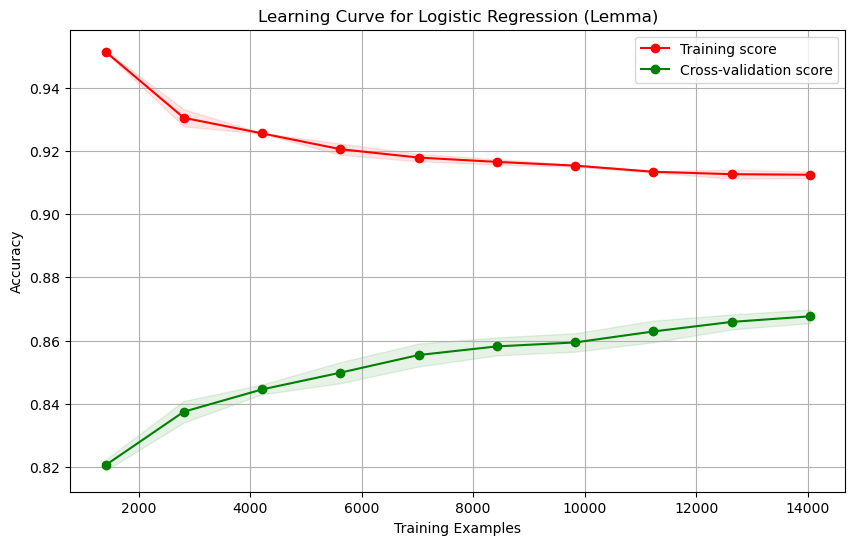

In [56]:
model = LogisticRegressionModel_l

# Generate learning curve data
train_sizes, train_scores, test_scores = learning_curve(
    model, xlv_test, yl_test, cv=5, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculate mean and standard deviation for training and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

# Fill the area between standard deviations
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")

plt.title("Learning Curve for Logistic Regression (Lemma)")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()
plt.show()

In [ ]:
# Hyper parameter tuning

# Define the hyperparameter grid
param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],  # Regularization type
    'C': [0.01, 0.1, 1, 10, 100],  # Regularization strength
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'saga'],  # Optimization algorithm
    'max_iter': [100, 200, 300]  # Maximum number of iterations
}

# Use GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(LR, param_grid, cv=5, scoring='accuracy')

# Fit the model
grid_search.fit(xlv_train, yl_train)

# Get the best hyperparameters
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

# Predict using the best model
best_model = grid_search.best_estimator_
pred_lr_lemma = best_model.predict(xlv_test)

# Check the accuracy score
accuracy = best_model.score(xlv_test, yl_test)
print("Accuracy:", accuracy)

# Save the model
LogisticRegression_Lemma_CV = best_model
with open('./Trained_Model/lrl_cv.pkl', 'wb') as model_file:
     pickle.dump(LogisticRegression_Lemma_CV, model_file)

c:\Users\User10\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\User10\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\User10\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\User10\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\User10\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\User10\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max

Best Hyperparameters: {'C': 1, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Accuracy: 0.8918641750227895


In [96]:
# Performance of Model
print("~~ Performance of Logistic Regression (Lemma) model \n\tafter hyperparameters tuning ~~\n")

pred = LogisticRegression_Lemma_CV.predict(xlv_test)
print("Accuracy:",LogisticRegression_Lemma_CV.score(xlv_test,yl_test),"\n")

print("Confusion Matrix:")
print(confusion_matrix(yl_test,pred))

print("\nClassification Report:")
print(classification_report(yl_test,pred))

~~ Performance of Logistic Regression (Lemma) model 
	after hyperparameters tuning ~~

Accuracy: 0.8918641750227895 

Confusion Matrix:
[[7090  916]
 [ 982 8564]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.89      0.88      8006
           1       0.90      0.90      0.90      9546

    accuracy                           0.89     17552
   macro avg       0.89      0.89      0.89     17552
weighted avg       0.89      0.89      0.89     17552



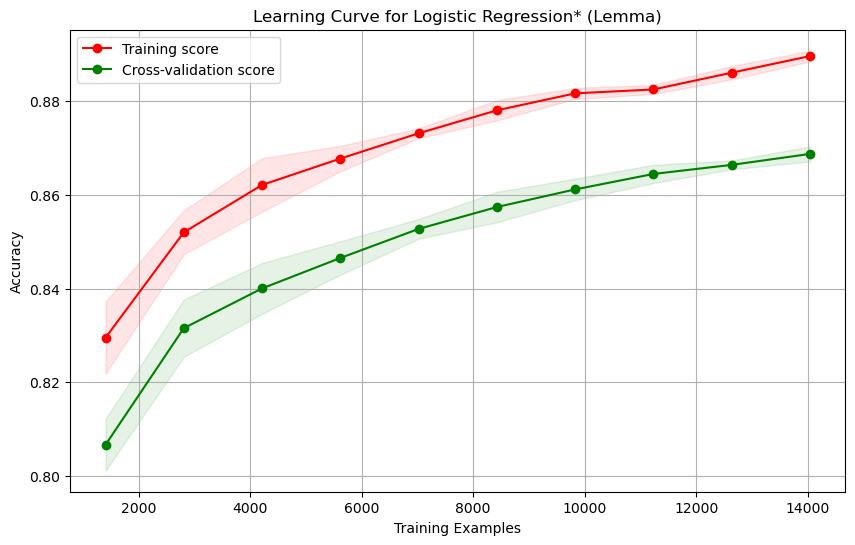

In [97]:
model = LogisticRegression_Lemma_CV

# Generate learning curve data
train_sizes, train_scores, test_scores = learning_curve(
    model, xlv_test, yl_test, cv=5, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculate mean and standard deviation for training and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

# Fill the area between standard deviations
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")

plt.title("Learning Curve for Logistic Regression* (Lemma)")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()
plt.show()

Logistic Regression (Stem)

In [ ]:
# Train Logistic Regression Model
LR = LogisticRegression()
LogisticRegressionModel_s = LR.fit(xsv_train, ys_train)

# Save the trained model to a pickle file
with open('./Trained_Model/lrs.pkl', 'wb') as model_file:
    pickle.dump(LogisticRegressionModel_s, model_file)

In [58]:
# Performance of Model
print("~~ Performance of Logistic Regression (Stem) model ~~\n")

pred = LogisticRegressionModel_s.predict(xsv_test)
print("Accuracy:",LogisticRegressionModel_s.score(xsv_test,ys_test),"\n")

print("Confusion Matrix:")
print(confusion_matrix(ys_test,pred))

print("\nClassification Report:")
print(classification_report(ys_test,pred))

~~ Performance of Logistic Regression (Stem) model ~~

Accuracy: 0.8904968094804011 

Confusion Matrix:
[[7023  983]
 [ 939 8607]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      8006
           1       0.90      0.90      0.90      9546

    accuracy                           0.89     17552
   macro avg       0.89      0.89      0.89     17552
weighted avg       0.89      0.89      0.89     17552



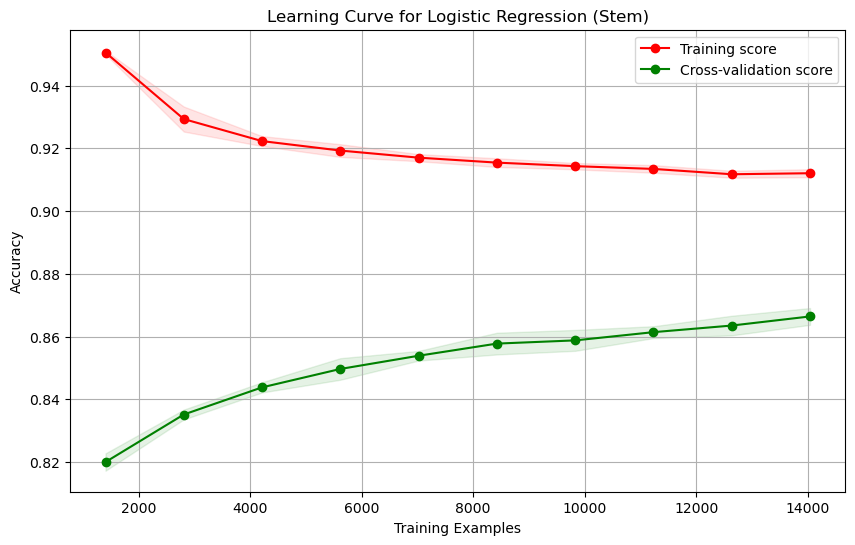

In [59]:
model = LogisticRegressionModel_s

# Generate learning curve data
train_sizes, train_scores, test_scores = learning_curve(
    model, xsv_test, ys_test, cv=5, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculate mean and standard deviation for training and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

# Fill the area between standard deviations
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")

plt.title("Learning Curve for Logistic Regression (Stem)")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()
plt.show()

In [ ]:
# Define the hyperparameter grid
param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],  # Regularization type
    'C': [0.01, 0.1, 1, 10, 100],  # Regularization strength
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'saga'],  # Optimization algorithm
    'max_iter': [100, 200, 300]  # Maximum number of iterations
}

# Use GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(LR, param_grid, cv=5, scoring='accuracy')

# Fit the model
grid_search.fit(xsv_train, ys_train)

# Get the best hyperparameters
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

# Predict using the best model
best_model = grid_search.best_estimator_
pred_lr_lemma = best_model.predict(xsv_test)

# Check the accuracy score
accuracy = best_model.score(xsv_test, ys_test)
print("Accuracy:", accuracy)

# Save the model
LogisticRegression_Stem_CV = best_model
with open('./Trained_Model/lrs_cv.pkl', 'wb') as model_file:
    pickle.dump(LogisticRegression_Stem_CV, model_file)

c:\Users\User10\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\User10\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\User10\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\User10\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\User10\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\User10\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max

Best Hyperparameters: {'C': 1, 'max_iter': 100, 'penalty': 'l1', 'solver': 'saga'}
Accuracy: 0.8920920692798542


c:\Users\User10\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [8]:
# Performance of Model
print("~~ Performance of Logistic Regression (Stem) model \n\tafter hyperparameters tuning ~~\n")

pred = LogisticRegression_Stem_CV.predict(xsv_test)
print("Accuracy:",LogisticRegression_Stem_CV.score(xsv_test,ys_test),"\n")

print("Confusion Matrix:")
print(confusion_matrix(ys_test,pred))

print("\nClassification Report:")
print(classification_report(ys_test,pred))

~~ Performance of Logistic Regression (Stem) model 
	after hyperparameters tuning ~~

Accuracy: 0.8920920692798542 

Confusion Matrix:
[[7085  921]
 [ 973 8573]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      8006
           1       0.90      0.90      0.90      9546

    accuracy                           0.89     17552
   macro avg       0.89      0.89      0.89     17552
weighted avg       0.89      0.89      0.89     17552



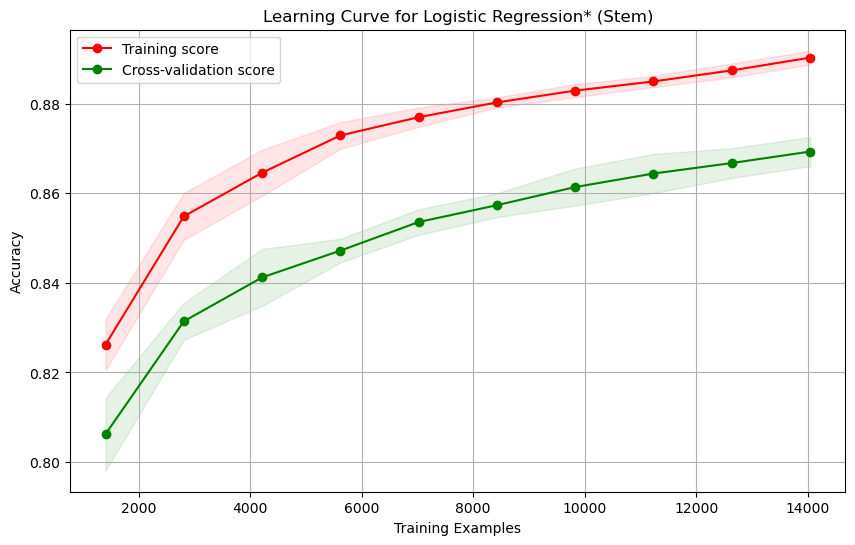

In [9]:
model = LogisticRegression_Stem_CV

# Generate learning curve data
train_sizes, train_scores, test_scores = learning_curve(
    model, xsv_test, ys_test, cv=5, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculate mean and standard deviation for training and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

# Fill the area between standard deviations
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")

plt.title("Learning Curve for Logistic Regression* (Stem)")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()
plt.show()

Random Forest (Lemma)

In [ ]:
# Train Random Forest Model
rfc = RandomForestClassifier()
RandomForestModel_l = rfc.fit(xlv_train, yl_train)

# Save the trained model to a pickle file
with open('./Trained_Model/rfl.pkl', 'wb') as model_file:
    pickle.dump(RandomForestModel_l, model_file)

In [82]:
# Performance of Model
print("~~ Performance of Random Forest (Lemma) model ~~\n")

pred = RandomForestModel_l.predict(xlv_test)
print("Accuracy:",RandomForestModel_l.score(xlv_test,yl_test),"\n")

print("Confusion Matrix:")
print(confusion_matrix(yl_test,pred))

print("\nClassification Report:")
print(classification_report(yl_test,pred))

~~ Performance of Random Forest (Lemma) model ~~

Accuracy: 0.8815519598906107 

Confusion Matrix:
[[6938 1068]
 [1011 8535]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      8006
           1       0.89      0.89      0.89      9546

    accuracy                           0.88     17552
   macro avg       0.88      0.88      0.88     17552
weighted avg       0.88      0.88      0.88     17552



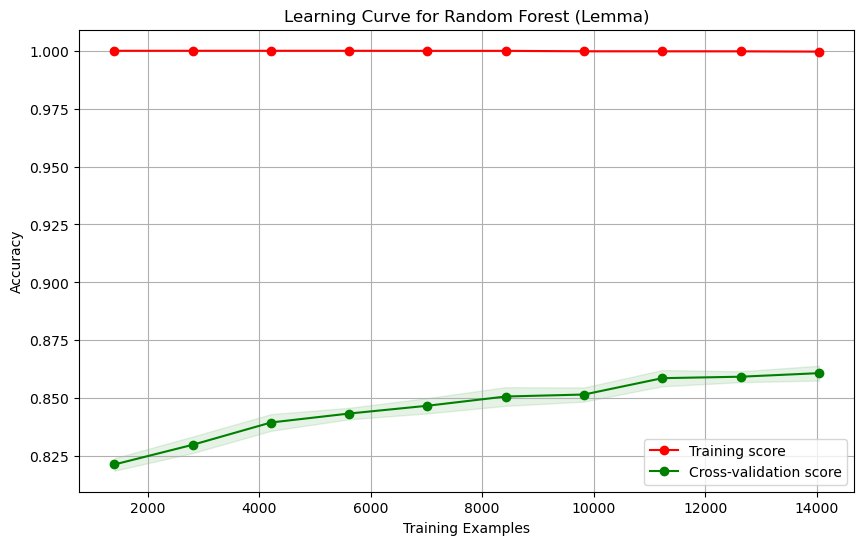

In [83]:
model = RandomForestModel_l

# Generate learning curve data
train_sizes, train_scores, test_scores = learning_curve(
    model, xlv_test, yl_test, cv=5, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculate mean and standard deviation for training and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

# Fill the area between standard deviations
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")

plt.title("Learning Curve for Random Forest (Lemma)")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import pickle

param_grid = {
    'n_estimators': [50, 100, 150], 
    'criterion': ['gini', 'entropy'],  
    'max_depth': [10, 20, None],  
    'min_samples_split': [2, 10],  
    'min_samples_leaf': [1, 5],  
    'max_features': ['sqrt', 'log2']  
}

# Initialize the RandomForestClassifier
rf = RandomForestClassifier(random_state=42)

# Use RandomizedSearchCV for faster hyperparameter tuning
random_search = RandomizedSearchCV(
    rf, param_distributions=param_grid, n_iter=100,  
    cv=5, scoring='accuracy', random_state=42, n_jobs=-1  
)

# Fit the model
random_search.fit(xlv_train, yl_train)

# Get the best model parameters
best_params = random_search.best_params_
print("Best Hyperparameters:", best_params)

# Predict using the best model
best_model = random_search.best_estimator_
pred_rf = best_model.predict(xlv_test)

# Check the accuracy score
accuracy = best_model.score(xlv_test, yl_test)
print("Accuracy:", accuracy)

# Save the model
RandomForestModel_Lemma_CV = best_model
with open('./Trained_Model/rfl_cv.pkl', 'wb') as model_file:
    pickle.dump(RandomForestModel_Lemma_CV, model_file)

Best Hyperparameters: {'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'gini'}
Accuracy: 0.8822926162260711


In [16]:
# Performance of Model
print("~~ Performance of Random Forest (Lemma) model \n\tafter hyperparameters tuning ~~\n")

pred = RandomForestModel_Lemma_CV.predict(xlv_test)
print("Accuracy:",RandomForestModel_Lemma_CV.score(xlv_test,yl_test),"\n")

print("Confusion Matrix:")
print(confusion_matrix(yl_test,pred))

print("\nClassification Report:")
print(classification_report(yl_test,pred))

~~ Performance of Random Forest (Lemma) model 
	after hyperparameters tuning ~~

Accuracy: 0.8822926162260711 

Confusion Matrix:
[[6855 1151]
 [ 915 8631]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      8006
           1       0.88      0.90      0.89      9546

    accuracy                           0.88     17552
   macro avg       0.88      0.88      0.88     17552
weighted avg       0.88      0.88      0.88     17552



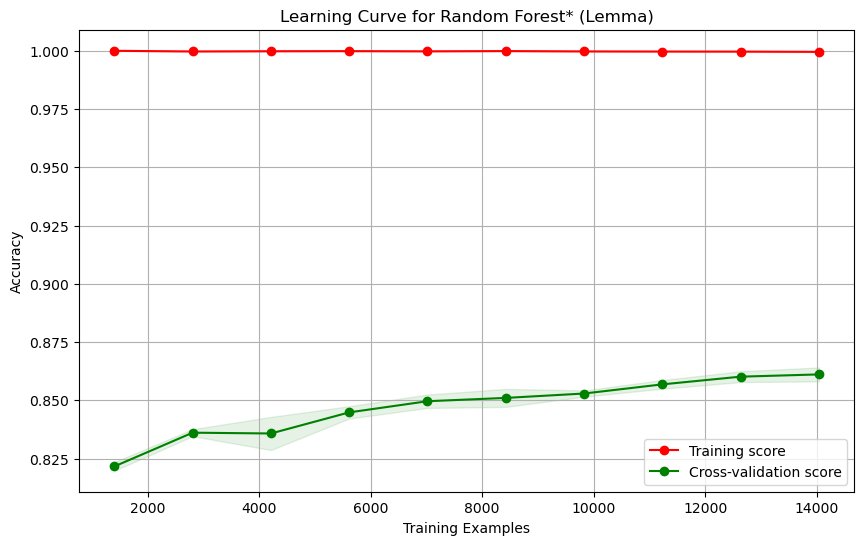

In [17]:
model = RandomForestModel_Lemma_CV

# Generate learning curve data
train_sizes, train_scores, test_scores = learning_curve(
    model, xlv_test, yl_test, cv=5, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculate mean and standard deviation for training and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

# Fill the area between standard deviations
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")

plt.title("Learning Curve for Random Forest* (Lemma)")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()
plt.show()

Random Forest (Stem)

In [ ]:
# Train Random Forest Model
rfc = RandomForestClassifier()
RandomForestModel_s = rfc.fit(xsv_train, ys_train)

# Save the trained model to a pickle file
with open('./Trained_Model/rfs.pkl', 'wb') as model_file:
    pickle.dump(RandomForestModel_s, model_file)

In [93]:
# Performance of Model
print("~~ Performance of Random Forest (Stem) model ~~\n")

pred = RandomForestModel_s.predict(xsv_test)
print("Accuracy:",RandomForestModel_s.score(xsv_test,ys_test),"\n")

print("Confusion Matrix:")
print(confusion_matrix(ys_test,pred))

print("\nClassification Report:")
print(classification_report(ys_test,pred))

~~ Performance of Random Forest (Stem) model ~~

Accuracy: 0.881950774840474 

Confusion Matrix:
[[6935 1071]
 [1001 8545]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      8006
           1       0.89      0.90      0.89      9546

    accuracy                           0.88     17552
   macro avg       0.88      0.88      0.88     17552
weighted avg       0.88      0.88      0.88     17552



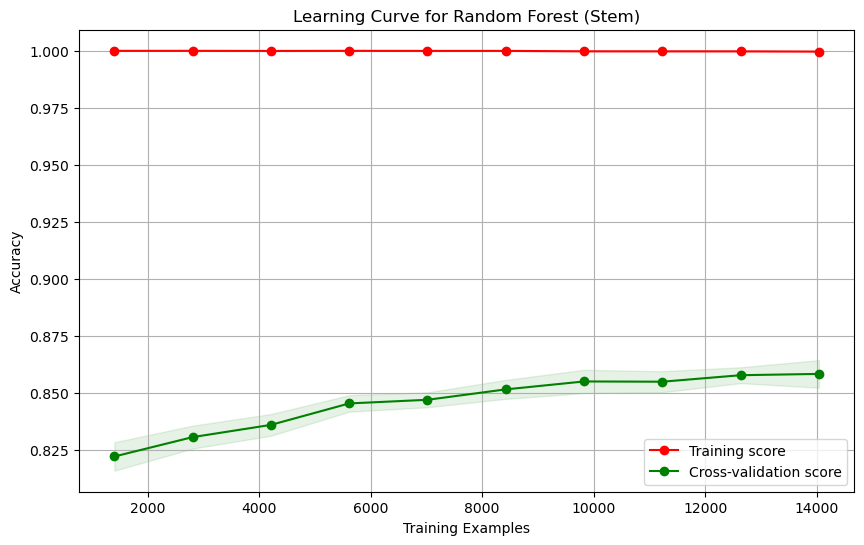

In [94]:
model = RandomForestModel_s

# Generate learning curve data
train_sizes, train_scores, test_scores = learning_curve(
    model, xsv_test, ys_test, cv=5, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculate mean and standard deviation for training and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

# Fill the area between standard deviations
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")

plt.title("Learning Curve for Random Forest (Stem)")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()
plt.show()

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 150],  
    'criterion': ['gini', 'entropy'],  
    'max_depth': [10, 20, None],  
    'min_samples_split': [2, 10],  
    'min_samples_leaf': [1, 5],  
    'max_features': ['sqrt', 'log2']  
}

# Initialize the RandomForestClassifier
rf = RandomForestClassifier(random_state=42)

# Use RandomizedSearchCV for faster hyperparameter tuning
random_search = RandomizedSearchCV(
    rf, param_distributions=param_grid, n_iter=100,  
    cv=5, scoring='accuracy', random_state=42, n_jobs=-1  
)

# Fit the model
random_search.fit(xsv_train, ys_train)

# Get the best model parameters
best_params = random_search.best_params_
print("Best Hyperparameters:", best_params)

# Predict using the best model
best_model = random_search.best_estimator_
pred_rf = best_model.predict(xsv_test)

# Check the accuracy score
accuracy = best_model.score(xsv_test, ys_test)
print("Accuracy:", accuracy)

# Save the model
RandomForestModel_Stem_CV = best_model
with open('./Trained_Model/rfs_cv.pkl', 'wb') as model_file:
    pickle.dump(RandomForestModel_Stem_CV, model_file)

Best Hyperparameters: {'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'gini'}
Accuracy: 0.8827484047402006


In [19]:
# Performance of Model
print("~~ Performance of Random Forest (Stem) model \n\tafter hyperparameters tuning ~~\n")

pred = RandomForestModel_Stem_CV.predict(xsv_test)
print("Accuracy:",RandomForestModel_Stem_CV.score(xsv_test,ys_test),"\n")

print("Confusion Matrix:")
print(confusion_matrix(ys_test,pred))

print("\nClassification Report:")
print(classification_report(ys_test,pred))

~~ Performance of Random Forest (Stem) model 
	after hyperparameters tuning ~~

Accuracy: 0.8827484047402006 

Confusion Matrix:
[[6890 1116]
 [ 942 8604]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      8006
           1       0.89      0.90      0.89      9546

    accuracy                           0.88     17552
   macro avg       0.88      0.88      0.88     17552
weighted avg       0.88      0.88      0.88     17552



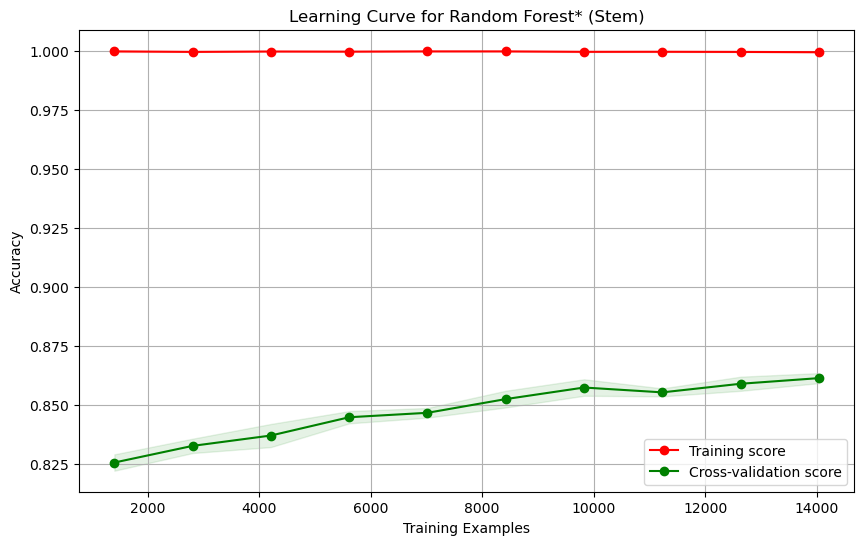

In [20]:
model = RandomForestModel_Stem_CV

# Generate learning curve data
train_sizes, train_scores, test_scores = learning_curve(
    model, xsv_test, ys_test, cv=5, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculate mean and standard deviation for training and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

# Fill the area between standard deviations
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")

plt.title("Learning Curve for Random Forest* (Stem)")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()
plt.show()

Decision Tree (Lemma)

In [ ]:
# Train Decision Tree Model
DTC = DecisionTreeClassifier()
DecisionTreeModel_l = DTC.fit(xlv_train, yl_train)

# Save the trained model to a pickle file
with open('./Trained_Model/dtl.pkl', 'wb') as model_file:
    pickle.dump(DecisionTreeModel_l, model_file)

In [61]:
# Performance of Model
print("~~ Performance of Decision Tree (Lemma) model ~~\n")

pred = DecisionTreeModel_l.predict(xlv_test)
print("Accuracy:",DecisionTreeModel_l.score(xlv_test,yl_test),"\n")

print("Confusion Matrix:")
print(confusion_matrix(yl_test,pred))

print("\nClassification Report:")
print(classification_report(yl_test,pred))

~~ Performance of Decision Tree (Lemma) model ~~

Accuracy: 0.8418983591613491 

Confusion Matrix:
[[6603 1403]
 [1372 8174]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.82      0.83      8006
           1       0.85      0.86      0.85      9546

    accuracy                           0.84     17552
   macro avg       0.84      0.84      0.84     17552
weighted avg       0.84      0.84      0.84     17552



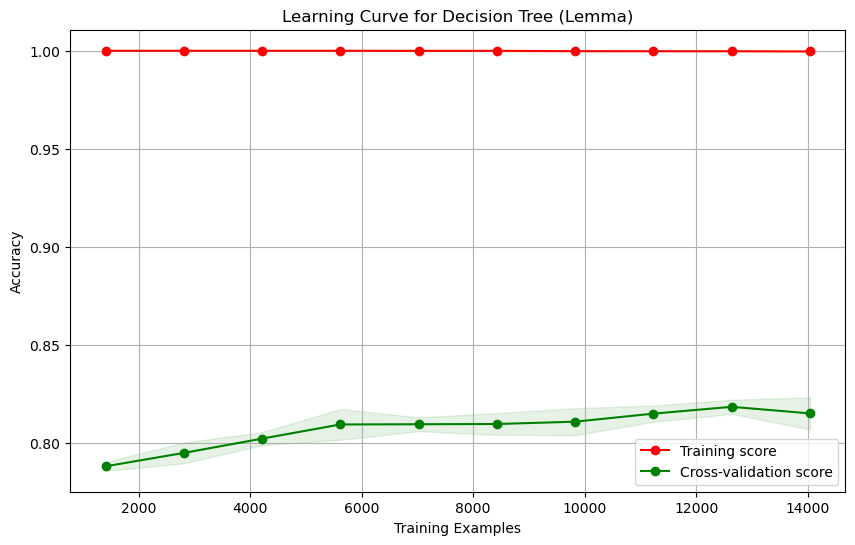

In [62]:
model = DecisionTreeModel_l

# Generate learning curve data
train_sizes, train_scores, test_scores = learning_curve(
    model, xlv_test, yl_test, cv=5, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculate mean and standard deviation for training and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

# Fill the area between standard deviations
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")

plt.title("Learning Curve for Decision Tree (Lemma)")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()
plt.show()

In [ ]:
# Hyper parameter tuning

# Define the hyperparameter grid to search
param_grid = {
    'criterion': ['gini', 'entropy'],  # Function to measure the quality of a split
    'max_depth': [None, 10, 20, 30],  # Maximum depth of the tree
    'min_samples_split': [2, 10, 20],  # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 5, 10],  # Minimum number of samples required to be at a leaf node
    'max_features': [None, 'sqrt', 'log2']  # Number of features to consider for the best split
}

# Use GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(DTC, param_grid, cv=5, scoring='accuracy')

# Fit the model
grid_search.fit(xlv_train, yl_train)

# Get the best model parameters
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

# Predict using the best model
best_model = grid_search.best_estimator_
pred_dtc_stem = best_model.predict(xlv_test)

# Check the accuracy score
accuracy = best_model.score(xlv_test, yl_test)
print("Accuracy:", accuracy)

# Save the model
DecisionTree_Lemma_CV = best_model
with open('./Trained_Model/dtl_cv.pkl', 'wb') as model_file:
     pickle.dump(DecisionTree_Lemma_CV, model_file)

Best Hyperparameters: {'criterion': 'gini', 'max_depth': 30, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy: 0.8510141294439381


In [88]:
# Performance of Model
print("~~ Performance of Decision Tree (Lemma) model \n\tafter hyperparameters tuning ~~\n")

pred = DecisionTree_Lemma_CV.predict(xlv_test)
print("Accuracy:",DecisionTree_Lemma_CV.score(xlv_test,yl_test),"\n")

print("Confusion Matrix:")
print(confusion_matrix(yl_test,pred))

print("\nClassification Report:")
print(classification_report(yl_test,pred))

~~ Performance of Decision Tree (Lemma) model 
	after hyperparameters tuning ~~

Accuracy: 0.8510141294439381 

Confusion Matrix:
[[6970 1036]
 [1579 7967]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.84      8006
           1       0.88      0.83      0.86      9546

    accuracy                           0.85     17552
   macro avg       0.85      0.85      0.85     17552
weighted avg       0.85      0.85      0.85     17552



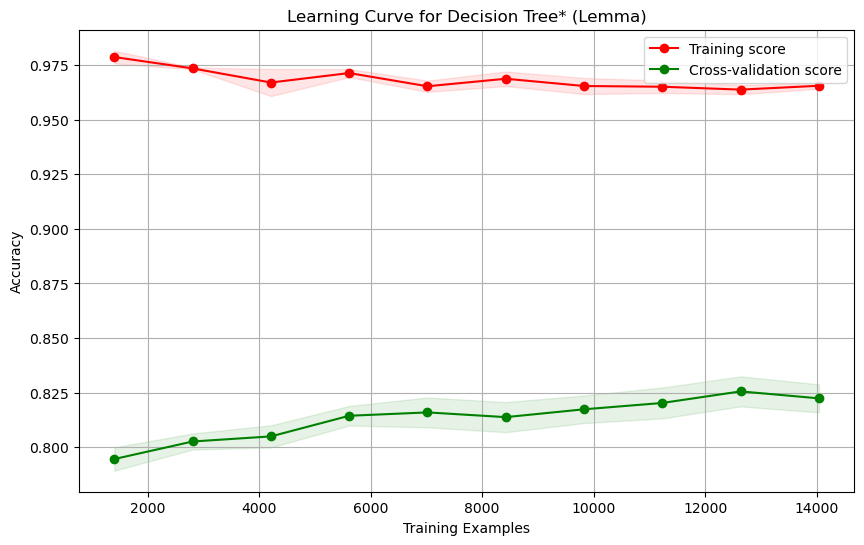

In [89]:
model = DecisionTree_Lemma_CV

# Generate learning curve data
train_sizes, train_scores, test_scores = learning_curve(
    model, xlv_test, yl_test, cv=5, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculate mean and standard deviation for training and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

# Fill the area between standard deviations
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")

plt.title("Learning Curve for Decision Tree* (Lemma)")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()
plt.show()

Decision Tree (Stem)

In [ ]:
# Train Decision Tree Model
DTC = DecisionTreeClassifier()
DecisionTreeModel_s = DTC.fit(xsv_train, ys_train)

# Save the trained model to a pickle file
with open('./Trained_Model/dts.pkl', 'wb') as model_file:
    pickle.dump(DecisionTreeModel_s, model_file)

In [64]:
# Performance of Model
print("~~ Performance of Decision Tree (Stem) model ~~\n")

pred = DecisionTreeModel_s.predict(xsv_test)
print("Accuracy:",DecisionTreeModel_s.score(xsv_test,ys_test),"\n")

print("Confusion Matrix:")
print(confusion_matrix(ys_test,pred))

print("\nClassification Report:")
print(classification_report(ys_test,pred))

~~ Performance of Decision Tree (Stem) model ~~

Accuracy: 0.8411007292616226 

Confusion Matrix:
[[6570 1436]
 [1353 8193]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.82      0.82      8006
           1       0.85      0.86      0.85      9546

    accuracy                           0.84     17552
   macro avg       0.84      0.84      0.84     17552
weighted avg       0.84      0.84      0.84     17552



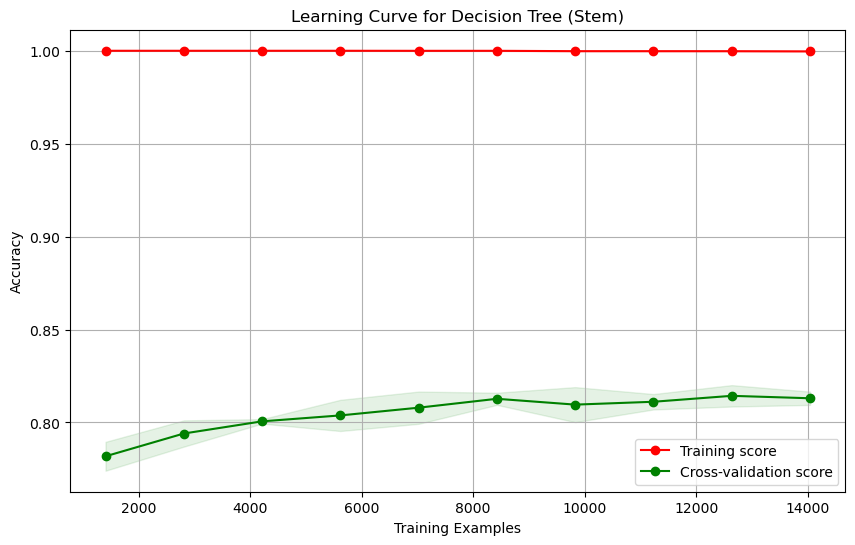

In [65]:
model = DecisionTreeModel_s

# Generate learning curve data
train_sizes, train_scores, test_scores = learning_curve(
    model, xsv_test, ys_test, cv=5, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculate mean and standard deviation for training and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

# Fill the area between standard deviations
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")

plt.title("Learning Curve for Decision Tree (Stem)")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()
plt.show()

In [ ]:
# Define the hyperparameter grid to search
param_grid = {
    'criterion': ['gini', 'entropy'],  # Function to measure the quality of a split
    'max_depth': [None, 10, 20, 30],  # Maximum depth of the tree
    'min_samples_split': [2, 10, 20],  # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 5, 10],  # Minimum number of samples required to be at a leaf node
    'max_features': [None, 'sqrt', 'log2']  # Number of features to consider for the best split
}

# Use GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(DTC, param_grid, cv=5, scoring='accuracy')

# Fit the model
grid_search.fit(xsv_train, ys_train)

# Get the best model parameters
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

# Predict using the best model
best_model = grid_search.best_estimator_
pred_dtc_stem = best_model.predict(xsv_test)

# Check the accuracy score
accuracy = best_model.score(xsv_test, ys_test)
print("Accuracy:", accuracy)

# Save the model
DecisionTree_Stem_CV = best_model
with open('./Trained_Model/dts_cv.pkl', 'wb') as model_file:
    pickle.dump(DecisionTree_Stem_CV, model_file)

Best Hyperparameters: {'criterion': 'gini', 'max_depth': 30, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 20}
Accuracy: 0.8530651777575206


In [11]:
# Performance of Model
print("~~ Performance of Decision Tree (Stem) model \n\tafter hyperparameters tuning ~~\n")

pred = DecisionTree_Stem_CV.predict(xsv_test)
print("Accuracy:",DecisionTree_Stem_CV.score(xsv_test,ys_test),"\n")

print("Confusion Matrix:")
print(confusion_matrix(ys_test,pred))

print("\nClassification Report:")
print(classification_report(ys_test,pred))

~~ Performance of Decision Tree (Stem) model 
	after hyperparameters tuning ~~

Accuracy: 0.8530651777575206 

Confusion Matrix:
[[6984 1022]
 [1557 7989]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.84      8006
           1       0.89      0.84      0.86      9546

    accuracy                           0.85     17552
   macro avg       0.85      0.85      0.85     17552
weighted avg       0.86      0.85      0.85     17552



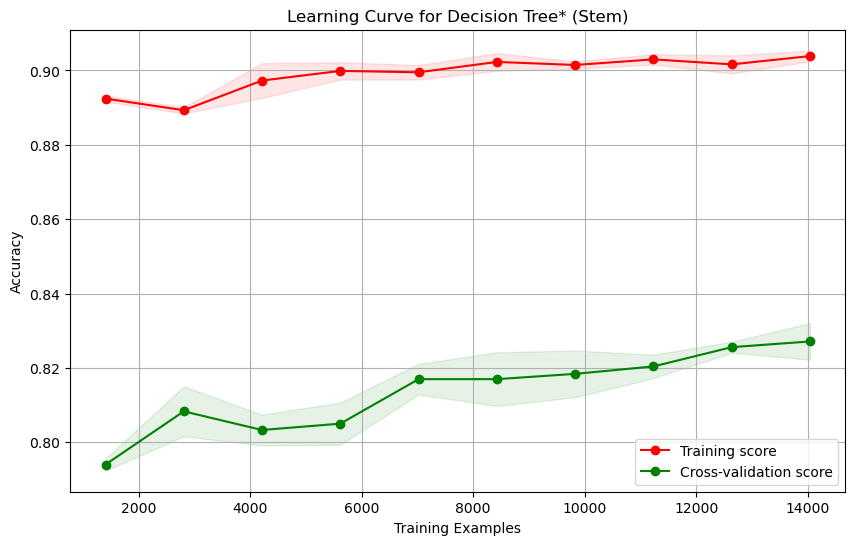

In [12]:
model = DecisionTree_Stem_CV

# Generate learning curve data
train_sizes, train_scores, test_scores = learning_curve(
    model, xsv_test, ys_test, cv=5, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculate mean and standard deviation for training and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

# Fill the area between standard deviations
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")

plt.title("Learning Curve for Decision Tree* (Stem)")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()
plt.show()

Convolutional Neural Network - CNN (Lemma)

In [ ]:
# import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, Dense, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l2

# Preprocessing: Tokenization and Padding
max_vocab_size = 10000  # Maximum number of words in the vocabulary
max_sequence_length = 100  # Maximum length of each input sequence

# Initialize tokenizer and fit on training text data
tokenizer = Tokenizer(num_words=max_vocab_size)
tokenizer.fit_on_texts(xl_train)  # xlv_train is the text training data

# Convert text to sequences
x_train_seq = tokenizer.texts_to_sequences(xl_train)
x_test_seq = tokenizer.texts_to_sequences(xl_test)

# Pad sequences to ensure uniform input length
x_train_pad = pad_sequences(x_train_seq, maxlen=max_sequence_length, padding='post')
x_test_pad = pad_sequences(x_test_seq, maxlen=max_sequence_length, padding='post')

# Define CNN Model
cnnl_model = Sequential([
    Embedding(input_dim=max_vocab_size, output_dim=128, input_length=max_sequence_length),  # Word embeddings
    Conv1D(filters=128, kernel_size=5, activation='relu', kernel_regularizer=l2(0.01)),  # Convolution layer
    GlobalMaxPooling1D(),  # Global pooling layer
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),  # Fully connected layer
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
cnnl_model.compile(optimizer='adam',
                  loss='binary_crossentropy',  # Use 'categorical_crossentropy' for multi-class
                  metrics=['accuracy'])

# Train the model
cnnl = cnnl_model.fit(x_train_pad, yl_train, epochs=20, batch_size=32, validation_data=(x_test_pad, yl_test))

# Evaluate the model
loss, accuracy = cnnl_model.evaluate(x_test_pad, yl_test)
print(f"Test Accuracy: {accuracy:.4f}")

# Save model
cnnl_model.save('./Trained_Model/cnnl.h5')

Epoch 1/20


c:\Users\User10\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


2194/2194 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - accuracy: 0.7665 - loss: 0.6684 - val_accuracy: 0.8573 - val_loss: 0.3773
Epoch 2/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.8762 - loss: 0.3456 - val_accuracy: 0.8543 - val_loss: 0.3671
Epoch 3/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.9005 - loss: 0.2917 - val_accuracy: 0.8579 - val_loss: 0.3639
Epoch 4/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.9220 - loss: 0.2475 - val_accuracy: 0.8545 - val_loss: 0.3762
Epoch 5/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.9416 - loss: 0.2025 - val_accuracy: 0.8533 - val_loss: 0.4006
Epoch 6/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.9559 - loss: 0.1708 - val_accuracy: 0.8477 - val_loss: 0.4298
Epoch 7/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.9668 - loss: 0.1427 - val_accuracy: 0.8508 - val_loss: 0.4729
Epoch 8/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.9721 - loss: 0.12

Test Accuracy: 0.8413


In [121]:
# Performance of Model
print("~~ Performance of CNN (Lemma) model ~~\n")

# Make predictions on the test set
y_pred_prob = cnnl_model.predict(x_test_pad)
y_pred = np.round(y_pred_prob).astype(int)

# Calculate accuracy
print("Accuracy: ", accuracy_score(yl_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(yl_test,y_pred))

print("\nClassification Report:")
print(classification_report(yl_test, y_pred))

~~ Performance of CNN (Lemma) model ~~

549/549 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy:  0.8412716499544212

Confusion Matrix:
[[6520 1486]
 [1300 8246]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      8006
           1       0.85      0.86      0.86      9546

    accuracy                           0.84     17552
   macro avg       0.84      0.84      0.84     17552
weighted avg       0.84      0.84      0.84     17552



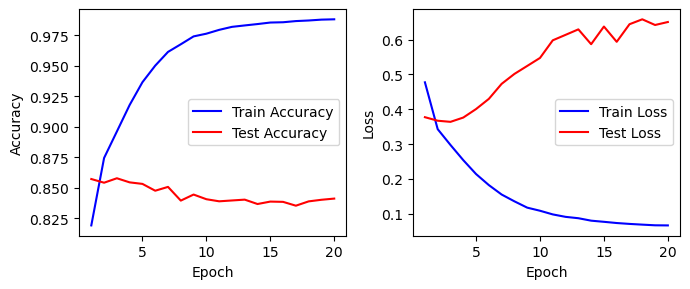

In [44]:
import matplotlib.pyplot as plt

acc2 = cnnl.history['accuracy']
val_acc2 = cnnl.history['val_accuracy']
loss2 = cnnl.history['loss']
val_loss = cnnl.history['val_loss']

ephocs = range(1, len(acc2) + 1)

# Creating Subplots
fig, axes = plt.subplots(nrows=1, ncols=2,figsize=(7,3))

axes[0].plot(ephocs, acc2, 'b', label='Train Accuracy')
axes[0].plot(ephocs, val_acc2, 'r', label='Test Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(ephocs, loss2, 'b', label='Train Loss')
axes[1].plot(ephocs, val_loss, 'r', label='Test Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

# Adjusting layout for better spacing
plt.tight_layout()
plt.show()

In [ ]:
# Hyper parameter tuning
from kerastuner import RandomSearch
from kerastuner.engine.hyperparameters import HyperParameters
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, Dense, Embedding, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# Preprocessing: Tokenization and Padding
max_vocab_size = 10000  # Maximum number of words in the vocabulary
max_sequence_length = 100  # Maximum length of each input sequence

# Initialize tokenizer and fit on training text data
tokenizer = Tokenizer(num_words=max_vocab_size)
tokenizer.fit_on_texts(xl_train)

# Convert text to sequences
x_train_seq = tokenizer.texts_to_sequences(xl_train)
x_test_seq = tokenizer.texts_to_sequences(xl_test)

# Pad sequences to ensure uniform input length
x_train_pad = pad_sequences(x_train_seq, maxlen=max_sequence_length, padding='post')
x_test_pad = pad_sequences(x_test_seq, maxlen=max_sequence_length, padding='post')

# Define model building function
def build_model(hp):
    model = Sequential([
        # Embedding layer
        Embedding(input_dim=max_vocab_size, 
                  output_dim=hp.Choice('embedding_dim', values=[64, 128, 256]), 
                  input_length=max_sequence_length),
        
        # Conv1D layer
        Conv1D(filters=hp.Int('filters', min_value=32, max_value=256, step=32),
               kernel_size=hp.Choice('kernel_size', values=[3, 5, 7]), 
               activation='relu',
               kernel_regularizer=l2(hp.Choice('l2_reg', values=[0.001, 0.01, 0.1]))),
        
        GlobalMaxPooling1D(),
        
        # Dense layer
        Dense(units=hp.Int('dense_units', min_value=32, max_value=128, step=32), 
              activation='relu',
              kernel_regularizer=l2(hp.Choice('l2_reg_dense', values=[0.001, 0.01, 0.1]))),
        
        Dropout(rate=hp.Choice('dropout_rate', values=[0.3, 0.5])),
        
        # Output layer
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam', 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
    return model

# Set up KerasTuner RandomSearch
tuner = RandomSearch(
    build_model,
    objective='val_accuracy',  # Optimization target
    max_trials=20,  # Number of hyperparameter combinations to try
    directory='cnn_hyperparameter_tuning',  # Folder to store tuning results
    project_name='cnn_tuning'
)

# Start hyperparameter search
tuner.search(x_train_pad, yl_train, 
             epochs=20,  # Number of epochs for each trial
             batch_size=32,  # Batch size
             validation_data=(x_test_pad, yl_test))

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best hyperparameters found:")
print(f"Embedding Dimension: {best_hps.get('embedding_dim')}")
print(f"Filters: {best_hps.get('filters')}")
print(f"Kernel Size: {best_hps.get('kernel_size')}")
print(f"L2 Regularization (Conv): {best_hps.get('l2_reg')}")
print(f"L2 Regularization (Dense): {best_hps.get('l2_reg_dense')}")
print(f"Dense Units: {best_hps.get('dense_units')}")
print(f"Dropout Rate: {best_hps.get('dropout_rate')}")

# Build and train the best model
cnnl_cv = tuner.hypermodel.build(best_hps)
cnnl_tuned = cnnl_cv.fit(x_train_pad, yl_train, 
                         epochs=20, 
                         batch_size=32, 
                         validation_data=(x_test_pad, yl_test))

# Evaluate the best model
loss, accuracy = cnnl_cv.evaluate(x_test_pad, yl_test)
print(f"Best Model Test Accuracy: {accuracy:.4f}")

# Save the best model
cnnl_cv.save('./Trained_Model/cnnl_tuned.h5')

C:\Users\User10\AppData\Local\Temp\ipykernel_19344\2292631209.py:2: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner import RandomSearch


Reloading Tuner from cnn_hyperparameter_tuning\cnn_tuning\tuner0.json
Best hyperparameters found:
Embedding Dimension: 256
Filters: 64
Kernel Size: 5
L2 Regularization (Conv): 0.001
L2 Regularization (Dense): 0.001
Dense Units: 96
Dropout Rate: 0.3
Epoch 1/20


c:\Users\User10\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


2194/2194 ━━━━━━━━━━━━━━━━━━━━ 37s 16ms/step - accuracy: 0.8060 - loss: 0.4695 - val_accuracy: 0.8686 - val_loss: 0.3450
Epoch 2/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 34s 15ms/step - accuracy: 0.9032 - loss: 0.2786 - val_accuracy: 0.8696 - val_loss: 0.3415
Epoch 3/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - accuracy: 0.9402 - loss: 0.1995 - val_accuracy: 0.8608 - val_loss: 0.3815
Epoch 4/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - accuracy: 0.9660 - loss: 0.1392 - val_accuracy: 0.8568 - val_loss: 0.4572
Epoch 5/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - accuracy: 0.9798 - loss: 0.1026 - val_accuracy: 0.8538 - val_loss: 0.4619
Epoch 6/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - accuracy: 0.9843 - loss: 0.0884 - val_accuracy: 0.8593 - val_loss: 0.5380
Epoch 7/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.9878 - loss: 0.0759 - val_accuracy: 0.8562 - val_loss: 0.5326
Epoch 8/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - accuracy: 0.9879 - loss: 0.07

Best Model Test Accuracy: 0.8495


In [126]:
# Performance of Model
print("~~ Performance of CNN (Lemma) model \n\tafter hyperparameters tuning ~~\n")

# Make predictions on the test set
y_pred_prob = cnnl_cv.predict(x_test_pad)
y_pred = np.round(y_pred_prob).astype(int)

# Calculate accuracy
print("Accuracy: ", accuracy_score(yl_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(yl_test,y_pred))

print("\nClassification Report:")
print(classification_report(yl_test, y_pred))

~~ Performance of CNN (Lemma) model 
	after hyperparameters tuning ~~

549/549 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Accuracy:  0.8494758432087511

Confusion Matrix:
[[6862 1144]
 [1498 8048]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84      8006
           1       0.88      0.84      0.86      9546

    accuracy                           0.85     17552
   macro avg       0.85      0.85      0.85     17552
weighted avg       0.85      0.85      0.85     17552



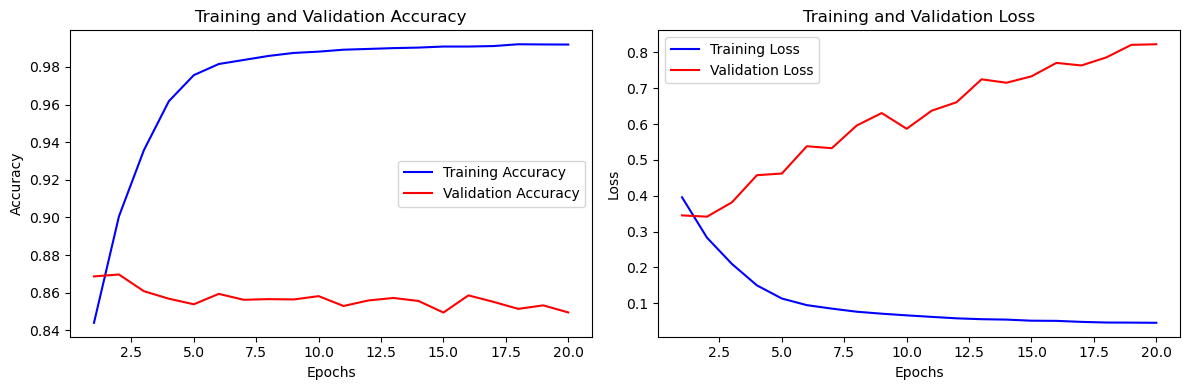

In [68]:
import matplotlib.pyplot as plt

# Extract accuracy and loss values from history
acc = cnnl_tuned.history['accuracy']
val_acc = cnnl_tuned.history['val_accuracy']
loss = cnnl_tuned.history['loss']
val_loss = cnnl_tuned.history['val_loss']

epochs = range(1, len(acc) + 1)

# Plot Learning Curves
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# Accuracy Plot
axes[0].plot(epochs, acc, 'b', label='Training Accuracy')
axes[0].plot(epochs, val_acc, 'r', label='Validation Accuracy')
axes[0].set_title('Training and Validation Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss Plot
axes[1].plot(epochs, loss, 'b', label='Training Loss')
axes[1].plot(epochs, val_loss, 'r', label='Validation Loss')
axes[1].set_title('Training and Validation Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

Convolutional Neural Network - CNN (Stem)

In [ ]:
# import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, Dense, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# Preprocessing: Tokenization and Padding
max_vocab_size = 10000  # Maximum number of words in the vocabulary
max_sequence_length = 100  # Maximum length of each input sequence

# Initialize tokenizer and fit on training text data
tokenizer = Tokenizer(num_words=max_vocab_size)
tokenizer.fit_on_texts(xs_train)  # xs_train is the text training data

# Convert text to sequences
x_train_seq = tokenizer.texts_to_sequences(xs_train)
x_test_seq = tokenizer.texts_to_sequences(xs_test)

# Pad sequences to ensure uniform input length
x_train_pad = pad_sequences(x_train_seq, maxlen=max_sequence_length, padding='post')
x_test_pad = pad_sequences(x_test_seq, maxlen=max_sequence_length, padding='post')

# Define CNN Model
cnns_model = Sequential([
    Embedding(input_dim=max_vocab_size, output_dim=128, input_length=max_sequence_length),  # Word embeddings
    Conv1D(filters=128, kernel_size=5, activation='relu'),  # Convolution layer
    GlobalMaxPooling1D(),  # Global pooling layer
    Dense(64, activation='relu'),  # Fully connected layer
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
cnns_model.compile(optimizer='adam',
                  loss='binary_crossentropy',  # Use 'categorical_crossentropy' for multi-class
                  metrics=['accuracy'])

# Train the model
cnns = cnns_model.fit(x_train_pad, ys_train, epochs=20, batch_size=32, validation_data=(x_test_pad, ys_test))

# Evaluate the model
loss, accuracy = cnns_model.evaluate(x_test_pad, ys_test)
print(f"Test Accuracy: {accuracy:.4f}")

# Save model
cnns_model.save('./Trained_Model/cnns.h5')

Epoch 1/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.8107 - loss: 0.3901 - val_accuracy: 0.8711 - val_loss: 0.2951
Epoch 2/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9276 - loss: 0.1891 - val_accuracy: 0.8741 - val_loss: 0.3117
Epoch 3/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.9765 - loss: 0.0792 - val_accuracy: 0.8696 - val_loss: 0.3782
Epoch 4/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.9897 - loss: 0.0408 - val_accuracy: 0.8663 - val_loss: 0.4336
Epoch 5/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.9918 - loss: 0.0283 - val_accuracy: 0.8711 - val_loss: 0.6094
Epoch 6/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.9919 - loss: 0.0214 - val_accuracy: 0.8673 - val_loss: 0.6267
Epoch 7/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.9932 - loss: 0.0158 - val_accuracy: 0.8630 - val_loss: 0.8341
Epoch 8/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - accuracy: 0.9932 -

Test Accuracy: 0.8638


In [118]:
# Performance of Model
print("~~ Performance of CNN (Stem) model ~~\n")

# Make predictions on the test set
y_pred_prob = cnns_model.predict(x_test_pad)
y_pred = np.round(y_pred_prob).astype(int)

# Calculate accuracy
print("Accuracy: ", accuracy_score(ys_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(ys_test,y_pred))

print("\nClassification Report:")
print(classification_report(ys_test, y_pred))

~~ Performance of CNN (Stem) model ~~

549/549 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy:  0.8638331814038286

Confusion Matrix:
[[6716 1290]
 [1100 8446]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      8006
           1       0.87      0.88      0.88      9546

    accuracy                           0.86     17552
   macro avg       0.86      0.86      0.86     17552
weighted avg       0.86      0.86      0.86     17552



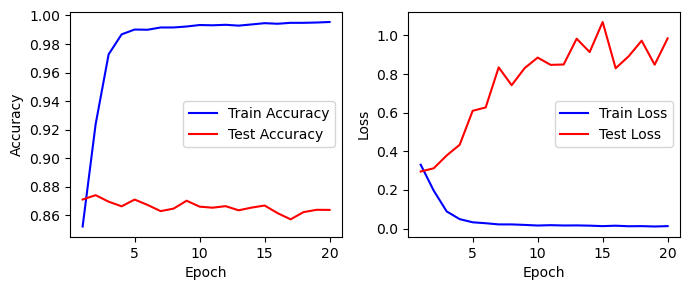

In [46]:
import matplotlib.pyplot as plt

acc2 = cnns.history['accuracy']
val_acc2 = cnns.history['val_accuracy']
loss2 = cnns.history['loss']
val_loss = cnns.history['val_loss']

ephocs = range(1, len(acc2) + 1)

# Creating Subplots
fig, axes = plt.subplots(nrows=1, ncols=2,figsize=(7,3))

axes[0].plot(ephocs, acc2, 'b', label='Train Accuracy')
axes[0].plot(ephocs, val_acc2, 'r', label='Test Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(ephocs, loss2, 'b', label='Train Loss')
axes[1].plot(ephocs, val_loss, 'r', label='Test Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

# Adjusting layout for better spacing
plt.tight_layout()
plt.show()

In [ ]:
# Hyper parameter tuning
from kerastuner import RandomSearch
from kerastuner.engine.hyperparameters import HyperParameters
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, Dense, Embedding, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# Preprocessing: Tokenization and Padding
max_vocab_size = 10000  # Maximum number of words in the vocabulary
max_sequence_length = 100  # Maximum length of each input sequence

# Initialize tokenizer and fit on training text data
tokenizer = Tokenizer(num_words=max_vocab_size)
tokenizer.fit_on_texts(xs_train)

# Convert text to sequences
x_train_seq = tokenizer.texts_to_sequences(xs_train)
x_test_seq = tokenizer.texts_to_sequences(xs_test)

# Pad sequences to ensure uniform input length
x_train_pad = pad_sequences(x_train_seq, maxlen=max_sequence_length, padding='post')
x_test_pad = pad_sequences(x_test_seq, maxlen=max_sequence_length, padding='post')

# Define model building function
def build_model(hp):
    model = Sequential([
        # Embedding layer
        Embedding(input_dim=max_vocab_size, 
                  output_dim=hp.Choice('embedding_dim', values=[64, 128, 256]), 
                  input_length=max_sequence_length),
        
        # Conv1D layer
        Conv1D(filters=hp.Int('filters', min_value=32, max_value=256, step=32),
               kernel_size=hp.Choice('kernel_size', values=[3, 5, 7]), 
               activation='relu',
               kernel_regularizer=l2(hp.Choice('l2_reg', values=[0.001, 0.01, 0.1]))),
        
        GlobalMaxPooling1D(),
        
        # Dense layer
        Dense(units=hp.Int('dense_units', min_value=32, max_value=128, step=32), 
              activation='relu',
              kernel_regularizer=l2(hp.Choice('l2_reg_dense', values=[0.001, 0.01, 0.1]))),
        
        Dropout(rate=hp.Choice('dropout_rate', values=[0.3, 0.5])),
        
        # Output layer
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam', 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
    return model

# Set up KerasTuner RandomSearch
tuner = RandomSearch(
    build_model,
    objective='val_accuracy',  # Optimization target
    max_trials=20,  # Number of hyperparameter combinations to try
    directory='cnn_hyperparameter_tuning',  # Folder to store tuning results
    project_name='cnn_tuning'
)

# Start hyperparameter search
tuner.search(x_train_pad, ys_train, 
             epochs=20,  # Number of epochs for each trial
             batch_size=32,  # Batch size
             validation_data=(x_test_pad, ys_test))

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best hyperparameters found:")
print(f"Embedding Dimension: {best_hps.get('embedding_dim')}")
print(f"Filters: {best_hps.get('filters')}")
print(f"Kernel Size: {best_hps.get('kernel_size')}")
print(f"L2 Regularization (Conv): {best_hps.get('l2_reg')}")
print(f"L2 Regularization (Dense): {best_hps.get('l2_reg_dense')}")
print(f"Dense Units: {best_hps.get('dense_units')}")
print(f"Dropout Rate: {best_hps.get('dropout_rate')}")

# Build and train the best model
cnns_cv = tuner.hypermodel.build(best_hps)
cnns_tuned = cnns_cv.fit(x_train_pad, yl_train, 
                         epochs=20, 
                         batch_size=32, 
                         validation_data=(x_test_pad, ys_test))

# Evaluate the best model
loss, accuracy = cnns_cv.evaluate(x_test_pad, ys_test)
print(f"Best Model Test Accuracy: {accuracy:.4f}")

# Save the best model
cnns_cv.save('./Trained_Model/cnns_tuned.h5')

Reloading Tuner from cnn_hyperparameter_tuning\cnn_tuning\tuner0.json
Best hyperparameters found:
Embedding Dimension: 256
Filters: 64
Kernel Size: 5
L2 Regularization (Conv): 0.001
L2 Regularization (Dense): 0.001
Dense Units: 96
Dropout Rate: 0.3
Epoch 1/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 38s 16ms/step - accuracy: 0.8058 - loss: 0.4711 - val_accuracy: 0.8634 - val_loss: 0.3524
Epoch 2/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - accuracy: 0.9037 - loss: 0.2792 - val_accuracy: 0.8733 - val_loss: 0.3413
Epoch 3/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 36s 16ms/step - accuracy: 0.9395 - loss: 0.2006 - val_accuracy: 0.8670 - val_loss: 0.3661
Epoch 4/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - accuracy: 0.9660 - loss: 0.1413 - val_accuracy: 0.8635 - val_loss: 0.4259
Epoch 5/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - accuracy: 0.9778 - loss: 0.1098 - val_accuracy: 0.8600 - val_loss: 0.4828
Epoch 6/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 38s 17ms/step - accuracy: 0.9836 - loss: 0.0926 -

Best Model Test Accuracy: 0.8577


In [125]:
# Performance of Model
print("~~ Performance of CNN (Stem) model \n\tafter hyperparameters tuning ~~\n")

# Make predictions on the test set
y_pred_prob = cnns_cv.predict(x_test_pad)
y_pred = np.round(y_pred_prob).astype(int)

# Calculate accuracy
print("Accuracy: ", accuracy_score(ys_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(ys_test,y_pred))

print("\nClassification Report:")
print(classification_report(ys_test, y_pred))

~~ Performance of CNN (Stem) model 
	after hyperparameters tuning ~~

549/549 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy:  0.8576800364630811

Confusion Matrix:
[[6682 1324]
 [1174 8372]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      8006
           1       0.86      0.88      0.87      9546

    accuracy                           0.86     17552
   macro avg       0.86      0.86      0.86     17552
weighted avg       0.86      0.86      0.86     17552



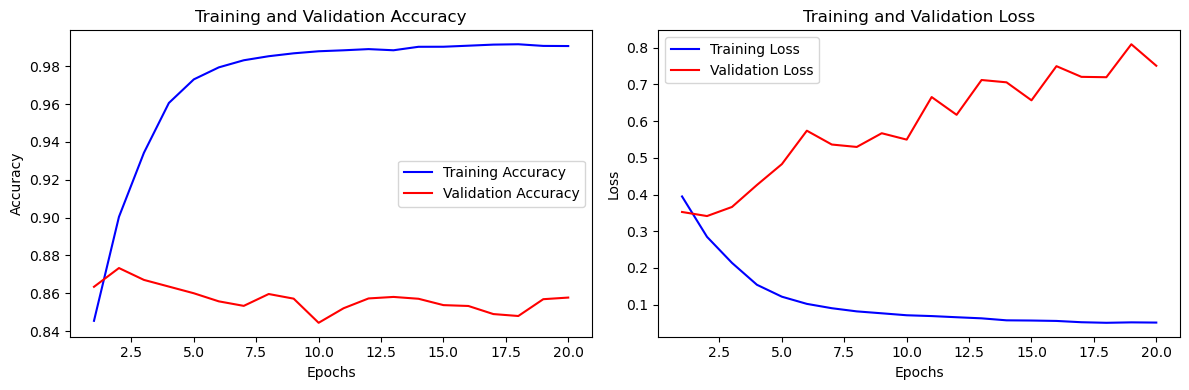

In [70]:
import matplotlib.pyplot as plt

# Extract accuracy and loss values from history
acc = cnns_tuned.history['accuracy']
val_acc = cnns_tuned.history['val_accuracy']
loss = cnns_tuned.history['loss']
val_loss = cnns_tuned.history['val_loss']

epochs = range(1, len(acc) + 1)

# Plot Learning Curves
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# Accuracy Plot
axes[0].plot(epochs, acc, 'b', label='Training Accuracy')
axes[0].plot(epochs, val_acc, 'r', label='Validation Accuracy')
axes[0].set_title('Training and Validation Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss Plot
axes[1].plot(epochs, loss, 'b', label='Training Loss')
axes[1].plot(epochs, val_loss, 'r', label='Validation Loss')
axes[1].set_title('Training and Validation Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

Recurrent Neural Network - RNN (Lemma)

In [ ]:
# import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# Preprocessing: Tokenization and Padding
max_vocab_size = 10000  # Maximum number of words in the vocabulary
max_sequence_length = 100  # Maximum length of each input sequence

# Initialize tokenizer and fit on training text data
tokenizer = Tokenizer(num_words=max_vocab_size)
tokenizer.fit_on_texts(xl_train)  # xl_train is the text training data

# Convert text to sequences
x_train_seq = tokenizer.texts_to_sequences(xl_train)
x_test_seq = tokenizer.texts_to_sequences(xl_test)

# Pad sequences to ensure uniform input length
x_train_pad = pad_sequences(x_train_seq, maxlen=max_sequence_length, padding='post')
x_test_pad = pad_sequences(x_test_seq, maxlen=max_sequence_length, padding='post')

# Define RNN Model
rnnl_model = Sequential([
    Embedding(input_dim=max_vocab_size, output_dim=128, input_length=max_sequence_length),  # Word embeddings
    SimpleRNN(128, activation='tanh'),  # Simple RNN layer
    Dense(64, activation='relu'),  # Fully connected layer
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
rnnl_model.compile(optimizer='adam',
                  loss='binary_crossentropy',  # Use 'categorical_crossentropy' for multi-class
                  metrics=['accuracy'])

# Train the model
rnn_l = rnnl_model.fit(x_train_pad, yl_train, epochs=20, batch_size=32, validation_data=(x_test_pad, yl_test))

# Evaluate the model
loss, accuracy = rnnl_model.evaluate(x_test_pad, yl_test)
print(f"Test Accuracy: {accuracy:.4f}")

# Save model
rnnl_model.save('./Trained_Model/rnn_l.h5')


Epoch 1/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - accuracy: 0.6954 - loss: 0.5425 - val_accuracy: 0.7125 - val_loss: 0.5552
Epoch 2/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 30s 13ms/step - accuracy: 0.7638 - loss: 0.4567 - val_accuracy: 0.7277 - val_loss: 0.4821
Epoch 3/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - accuracy: 0.7907 - loss: 0.4158 - val_accuracy: 0.7658 - val_loss: 0.4712
Epoch 4/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - accuracy: 0.8071 - loss: 0.3808 - val_accuracy: 0.7285 - val_loss: 0.5112
Epoch 5/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - accuracy: 0.7954 - loss: 0.3608 - val_accuracy: 0.7383 - val_loss: 0.4948
Epoch 6/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - accuracy: 0.8040 - loss: 0.3452 - val_accuracy: 0.7366 - val_loss: 0.5320
Epoch 7/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - accuracy: 0.8116 - loss: 0.3246 - val_accuracy: 0.7279 - val_loss: 0.5791
Epoch 8/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - accuracy: 0.8174 -

Test Accuracy: 0.7088


In [122]:
# Performance of Model
print("~~ Performance of RNN (Lemma) model ~~\n")

# Make predictions on the test set
y_pred_prob = rnnl_model.predict(x_test_pad)
y_pred = np.round(y_pred_prob).astype(int)

# Calculate accuracy
print("Accuracy: ", accuracy_score(yl_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(yl_test,y_pred))

print("\nClassification Report:")
print(classification_report(yl_test, y_pred))

~~ Performance of RNN (Lemma) model ~~

549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
Accuracy:  0.7088081130355515

Confusion Matrix:
[[6769 1237]
 [3874 5672]]

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.85      0.73      8006
           1       0.82      0.59      0.69      9546

    accuracy                           0.71     17552
   macro avg       0.73      0.72      0.71     17552
weighted avg       0.74      0.71      0.71     17552



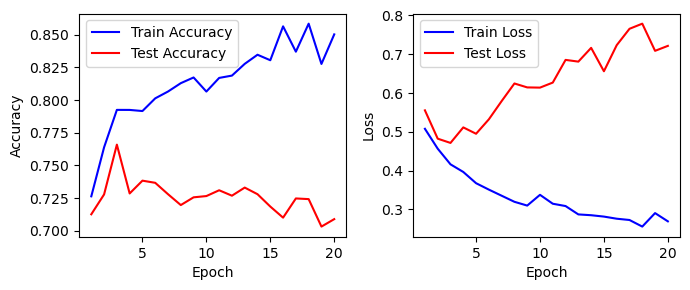

In [51]:
import matplotlib.pyplot as plt

acc2 = rnn_l.history['accuracy']
val_acc2 = rnn_l.history['val_accuracy']
loss2 = rnn_l.history['loss']
val_loss = rnn_l.history['val_loss']

ephocs = range(1, len(acc2) + 1)

# Creating Subplots
fig, axes = plt.subplots(nrows=1, ncols=2,figsize=(7,3))

axes[0].plot(ephocs, acc2, 'b', label='Train Accuracy')
axes[0].plot(ephocs, val_acc2, 'r', label='Test Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(ephocs, loss2, 'b', label='Train Loss')
axes[1].plot(ephocs, val_loss, 'r', label='Test Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

# Adjusting layout for better spacing
plt.tight_layout()
plt.show()

In [ ]:
# Hyper parameters tuning

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from kerastuner.tuners import RandomSearch
from kerastuner.engine.hyperparameters import HyperParameters

# Preprocessing: Tokenization and Padding
max_vocab_size = 10000  # Maximum number of words in the vocabulary
max_sequence_length = 100  # Maximum length of each input sequence

# Initialize tokenizer and fit on training text data
tokenizer = Tokenizer(num_words=max_vocab_size)
tokenizer.fit_on_texts(xl_train)  # xl_train is the text training data

# Convert text to sequences
x_train_seq = tokenizer.texts_to_sequences(xl_train)
x_test_seq = tokenizer.texts_to_sequences(xl_test)

# Pad sequences to ensure uniform input length
x_train_pad = pad_sequences(x_train_seq, maxlen=max_sequence_length, padding='post')
x_test_pad = pad_sequences(x_test_seq, maxlen=max_sequence_length, padding='post')

# Define a model-building function for KerasTuner
def build_model(hp):
    model = Sequential()
    # Hyperparameter for embedding dimension
    model.add(Embedding(input_dim=max_vocab_size,
                        output_dim=hp.Choice('embedding_dim', values=[64, 128, 256]),
                        input_length=max_sequence_length))
    # Hyperparameter for the number of units in the RNN layer
    model.add(SimpleRNN(units=hp.Int('rnn_units', min_value=32, max_value=256, step=32), 
                        activation='tanh'))
    # Hyperparameter for the number of units in the Dense layer
    model.add(Dense(units=hp.Int('dense_units', min_value=32, max_value=128, step=32), 
                    activation='relu'))
    # Output layer
    model.add(Dense(1, activation='sigmoid'))
    
    # Compile the model with hyperparameter-tuned learning rate
    model.compile(optimizer=tf.keras.optimizers.Adam(
                    learning_rate=hp.Choice('learning_rate', values=[1e-3, 1e-4, 1e-5])),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Initialize KerasTuner RandomSearch
tuner = RandomSearch(
    build_model,
    objective='val_accuracy',  # Optimize for validation accuracy
    max_trials=20,  # Number of hyperparameter combinations to try
    executions_per_trial=1,  # Number of times to train each model
    directory='rnn_tuning',  # Directory to save tuning results
    project_name='rnn_hyperparameter_tuning'
)

# Start the search
tuner.search(x_train_pad, yl_train, 
             epochs=20,  # Number of epochs for each trial
             batch_size=32, 
             validation_data=(x_test_pad, yl_test))

# Get the best model
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
The optimal embedding dimension is {best_hps.get('embedding_dim')}.
The optimal number of RNN units is {best_hps.get('rnn_units')}.
The optimal number of Dense units is {best_hps.get('dense_units')}.
The optimal learning rate is {best_hps.get('learning_rate')}.
""")

# Train the best model
rnn_l_cv_model = tuner.hypermodel.build(best_hps)
rnnl_cv = rnn_l_cv_model.fit(x_train_pad, yl_train, 
                         epochs=20, 
                         batch_size=32, 
                         validation_data=(x_test_pad, yl_test))

# Evaluate the model
loss, accuracy = rnn_l_cv_model.evaluate(x_test_pad, yl_test)
print(f"Test Accuracy: {accuracy:.4f}")

# Save the best model
rnn_l_cv_model.save('./Trained_Model/rnnl_tuned.h5')

Trial 20 Complete [00h 17m 42s]
val_accuracy: 0.8781335353851318

Best val_accuracy So Far: 0.8781335353851318
Total elapsed time: 1d 06h 35m 28s

The optimal embedding dimension is 128.
The optimal number of RNN units is 224.
The optimal number of Dense units is 32.
The optimal learning rate is 0.0001.

Epoch 1/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 54s 24ms/step - accuracy: 0.6695 - loss: 0.5873 - val_accuracy: 0.8493 - val_loss: 0.3477
Epoch 2/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 51s 23ms/step - accuracy: 0.8797 - loss: 0.2969 - val_accuracy: 0.8765 - val_loss: 0.2988
Epoch 3/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 52s 24ms/step - accuracy: 0.9120 - loss: 0.2292 - val_accuracy: 0.8798 - val_loss: 0.2968
Epoch 4/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 51s 23ms/step - accuracy: 0.9305 - loss: 0.1856 - val_accuracy: 0.8722 - val_loss: 0.3264
Epoch 5/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 51s 23ms/step - accuracy: 0.9537 - loss: 0.1314 - val_accuracy: 0.8669 - val_loss: 0.3856
Epoch 6/20
2194/2194 ━━━━━━━━━━━━━

Test Accuracy: 0.8519


In [123]:
# Performance of Model
print("~~ Performance of RNN (Lemma) model \n\tafter hyperparameters tuning ~~\n")

# Make predictions on the test set
y_pred_prob = rnn_l_cv_model.predict(x_test_pad)
y_pred = np.round(y_pred_prob).astype(int)

# Calculate accuracy
print("Accuracy: ", accuracy_score(yl_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(yl_test,y_pred))

print("\nClassification Report:")
print(classification_report(yl_test, y_pred))

~~ Performance of RNN (Lemma) model 
	after hyperparameters tuning ~~

549/549 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step
Accuracy:  0.8519257064721969

Confusion Matrix:
[[6559 1447]
 [1152 8394]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.82      0.83      8006
           1       0.85      0.88      0.87      9546

    accuracy                           0.85     17552
   macro avg       0.85      0.85      0.85     17552
weighted avg       0.85      0.85      0.85     17552



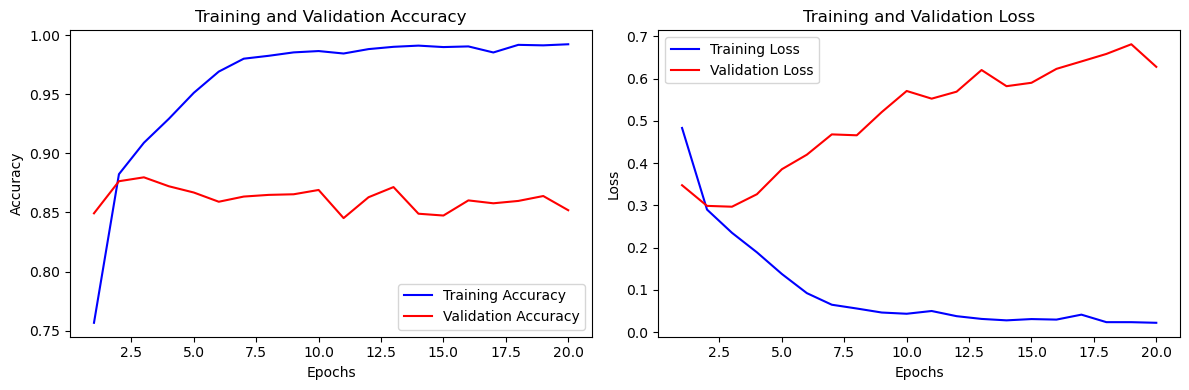

In [72]:
import matplotlib.pyplot as plt

# Extract accuracy and loss values from history
acc = rnnl_cv.history['accuracy']
val_acc = rnnl_cv.history['val_accuracy']
loss = rnnl_cv.history['loss']
val_loss = rnnl_cv.history['val_loss']

epochs = range(1, len(acc) + 1)

# Plot Learning Curves
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# Accuracy Plot
axes[0].plot(epochs, acc, 'b', label='Training Accuracy')
axes[0].plot(epochs, val_acc, 'r', label='Validation Accuracy')
axes[0].set_title('Training and Validation Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss Plot
axes[1].plot(epochs, loss, 'b', label='Training Loss')
axes[1].plot(epochs, val_loss, 'r', label='Validation Loss')
axes[1].set_title('Training and Validation Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

Recurrent Neural Network - RNN (Stem)

In [ ]:
# import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# Preprocessing: Tokenization and Padding
max_vocab_size = 10000  # Maximum number of words in the vocabulary
max_sequence_length = 100  # Maximum length of each input sequence

# Initialize tokenizer and fit on training text data
tokenizer = Tokenizer(num_words=max_vocab_size)
tokenizer.fit_on_texts(xs_train)  # xs_train is the text training data

# Convert text to sequences
x_train_seq = tokenizer.texts_to_sequences(xs_train)
x_test_seq = tokenizer.texts_to_sequences(xs_test)

# Pad sequences to ensure uniform input length
x_train_pad = pad_sequences(x_train_seq, maxlen=max_sequence_length, padding='post')
x_test_pad = pad_sequences(x_test_seq, maxlen=max_sequence_length, padding='post')

# Define RNN Model
rnns_model = Sequential([
    Embedding(input_dim=max_vocab_size, output_dim=128, input_length=max_sequence_length),  # Word embeddings
    SimpleRNN(128, activation='tanh'),  # Simple RNN layer
    Dense(64, activation='relu'),  # Fully connected layer
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
rnns_model.compile(optimizer='adam',
                  loss='binary_crossentropy',  # Use 'categorical_crossentropy' for multi-class
                  metrics=['accuracy'])

# Train the model
rnn_s = rnns_model.fit(x_train_pad, ys_train, epochs=20, batch_size=32, validation_data=(x_test_pad, ys_test))

# Evaluate the model
loss, accuracy = rnns_model.evaluate(x_test_pad, ys_test)
print(f"Test Accuracy: {accuracy:.4f}")

# Save model
rnns_model.save('./Trained_Model/rnn_s.h5')


Epoch 1/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - accuracy: 0.6815 - loss: 0.5628 - val_accuracy: 0.7910 - val_loss: 0.4535
Epoch 2/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - accuracy: 0.7671 - loss: 0.4551 - val_accuracy: 0.7349 - val_loss: 0.4793
Epoch 3/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - accuracy: 0.7525 - loss: 0.4557 - val_accuracy: 0.7113 - val_loss: 0.5212
Epoch 4/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - accuracy: 0.7588 - loss: 0.4416 - val_accuracy: 0.7383 - val_loss: 0.4840
Epoch 5/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - accuracy: 0.7782 - loss: 0.4082 - val_accuracy: 0.7286 - val_loss: 0.5046
Epoch 6/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - accuracy: 0.7711 - loss: 0.4224 - val_accuracy: 0.7197 - val_loss: 0.5274
Epoch 7/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - accuracy: 0.7534 - loss: 0.4537 - val_accuracy: 0.7145 - val_loss: 0.5209
Epoch 8/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - accuracy: 0.7573 -

Test Accuracy: 0.7188


In [111]:
# Performance of Model
print("~~ Performance of RNN (Stem) model ~~\n")

# Make predictions on the test set
y_pred_prob = rnns_model.predict(x_test_pad)
y_pred = np.round(y_pred_prob).astype(int)

# Calculate accuracy
print("Accuracy: ", accuracy_score(ys_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(ys_test,y_pred))

print("\nClassification Report:")
print(classification_report(ys_test, y_pred))

~~ Performance of RNN (Stem) model ~~

549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
Accuracy:  0.7188354603463992

Confusion Matrix:
[[4000 4006]
 [ 929 8617]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.50      0.62      8006
           1       0.68      0.90      0.78      9546

    accuracy                           0.72     17552
   macro avg       0.75      0.70      0.70     17552
weighted avg       0.74      0.72      0.70     17552



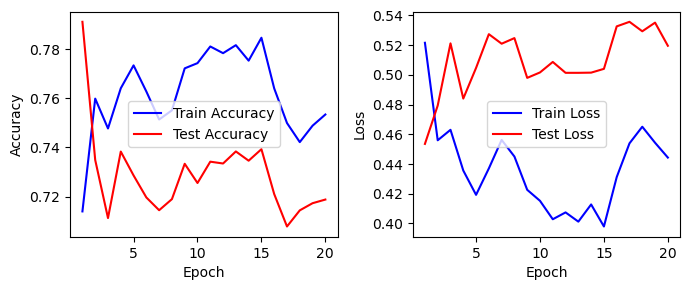

In [53]:
import matplotlib.pyplot as plt

acc2 = rnn_s.history['accuracy']
val_acc2 = rnn_s.history['val_accuracy']
loss2 = rnn_s.history['loss']
val_loss = rnn_s.history['val_loss']

ephocs = range(1, len(acc2) + 1)

# Creating Subplots
fig, axes = plt.subplots(nrows=1, ncols=2,figsize=(7,3))

axes[0].plot(ephocs, acc2, 'b', label='Train Accuracy')
axes[0].plot(ephocs, val_acc2, 'r', label='Test Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(ephocs, loss2, 'b', label='Train Loss')
axes[1].plot(ephocs, val_loss, 'r', label='Test Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

# Adjusting layout for better spacing
plt.tight_layout()
plt.show()

In [ ]:
# Hyper parameters tuning

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from kerastuner.tuners import RandomSearch
from kerastuner.engine.hyperparameters import HyperParameters

# Preprocessing: Tokenization and Padding
max_vocab_size = 10000  # Maximum number of words in the vocabulary
max_sequence_length = 100  # Maximum length of each input sequence

# Initialize tokenizer and fit on training text data
tokenizer = Tokenizer(num_words=max_vocab_size)
tokenizer.fit_on_texts(xs_train)  # xs_train is the text training data

# Convert text to sequences
x_train_seq = tokenizer.texts_to_sequences(xs_train)
x_test_seq = tokenizer.texts_to_sequences(xs_test)

# Pad sequences to ensure uniform input length
x_train_pad = pad_sequences(x_train_seq, maxlen=max_sequence_length, padding='post')
x_test_pad = pad_sequences(x_test_seq, maxlen=max_sequence_length, padding='post')

# Define a model-building function for KerasTuner
def build_model(hp):
    model = Sequential()
    # Hyperparameter for embedding dimension
    model.add(Embedding(input_dim=max_vocab_size,
                        output_dim=hp.Choice('embedding_dim', values=[64, 128, 256]),
                        input_length=max_sequence_length))
    # Hyperparameter for the number of units in the RNN layer
    model.add(SimpleRNN(units=hp.Int('rnn_units', min_value=32, max_value=256, step=32), 
                        activation='tanh'))
    # Hyperparameter for the number of units in the Dense layer
    model.add(Dense(units=hp.Int('dense_units', min_value=32, max_value=128, step=32), 
                    activation='relu'))
    # Output layer
    model.add(Dense(1, activation='sigmoid'))
    
    # Compile the model with hyperparameter-tuned learning rate
    model.compile(optimizer=tf.keras.optimizers.Adam(
                    learning_rate=hp.Choice('learning_rate', values=[1e-3, 1e-4, 1e-5])),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Initialize KerasTuner RandomSearch
tuner = RandomSearch(
    build_model,
    objective='val_accuracy',  # Optimize for validation accuracy
    max_trials=20,  # Number of hyperparameter combinations to try
    executions_per_trial=1,  # Number of times to train each model
    directory='rnn_tuning',  # Directory to save tuning results
    project_name='rnn_hyperparameter_tuning'
)

# Start the search
tuner.search(x_train_pad, ys_train, 
             epochs=20,  # Number of epochs for each trial
             batch_size=32, 
             validation_data=(x_test_pad, ys_test))

# Get the best model
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
The optimal embedding dimension is {best_hps.get('embedding_dim')}.
The optimal number of RNN units is {best_hps.get('rnn_units')}.
The optimal number of Dense units is {best_hps.get('dense_units')}.
The optimal learning rate is {best_hps.get('learning_rate')}.
""")

# Train the best model
rnn_s_cv_model = tuner.hypermodel.build(best_hps)
rnns_cv = rnn_s_cv_model.fit(x_train_pad, ys_train, 
                         epochs=20, 
                         batch_size=32, 
                         validation_data=(x_test_pad, ys_test))

# Evaluate the model
loss, accuracy = rnn_s_cv_model.evaluate(x_test_pad, ys_test)
print(f"Test Accuracy: {accuracy:.4f}")

# Save the best model
rnn_s_cv_model.save('./Trained_Model/rnns_tuned.h5')


Reloading Tuner from rnn_tuning\rnn_hyperparameter_tuning\tuner0.json

The optimal embedding dimension is 128.
The optimal number of RNN units is 224.
The optimal number of Dense units is 32.
The optimal learning rate is 0.0001.

Epoch 1/20


c:\Users\User10\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


2194/2194 ━━━━━━━━━━━━━━━━━━━━ 51s 22ms/step - accuracy: 0.6939 - loss: 0.5583 - val_accuracy: 0.8614 - val_loss: 0.3276
Epoch 2/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 47s 22ms/step - accuracy: 0.8853 - loss: 0.2853 - val_accuracy: 0.8798 - val_loss: 0.2962
Epoch 3/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 47s 22ms/step - accuracy: 0.9161 - loss: 0.2203 - val_accuracy: 0.8749 - val_loss: 0.3004
Epoch 4/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 47s 21ms/step - accuracy: 0.9459 - loss: 0.1565 - val_accuracy: 0.8666 - val_loss: 0.3971
Epoch 5/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 47s 21ms/step - accuracy: 0.9643 - loss: 0.1083 - val_accuracy: 0.8672 - val_loss: 0.3732
Epoch 6/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 48s 22ms/step - accuracy: 0.9770 - loss: 0.0717 - val_accuracy: 0.8674 - val_loss: 0.4289
Epoch 7/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 47s 21ms/step - accuracy: 0.9833 - loss: 0.0551 - val_accuracy: 0.8661 - val_loss: 0.4642
Epoch 8/20
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 47s 21ms/step - accuracy: 0.9865 - loss: 0.04

Test Accuracy: 0.8571


In [112]:
# Performance of Model
print("~~ Performance of RNN (Stem) model \n\tafter hyperparameters tuning ~~\n")

# Make predictions on the test set
y_pred_prob = rnn_s_cv_model.predict(x_test_pad)
y_pred = np.round(y_pred_prob).astype(int)

# Calculate accuracy
print("Accuracy: ", accuracy_score(ys_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(ys_test,y_pred))

print("\nClassification Report:")
print(classification_report(ys_test, y_pred))

~~ Performance of RNN (Stem) model 
	after hyperparameters tuning ~~

549/549 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step
Accuracy:  0.8571103008204193

Confusion Matrix:
[[6708 1298]
 [1210 8336]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      8006
           1       0.87      0.87      0.87      9546

    accuracy                           0.86     17552
   macro avg       0.86      0.86      0.86     17552
weighted avg       0.86      0.86      0.86     17552



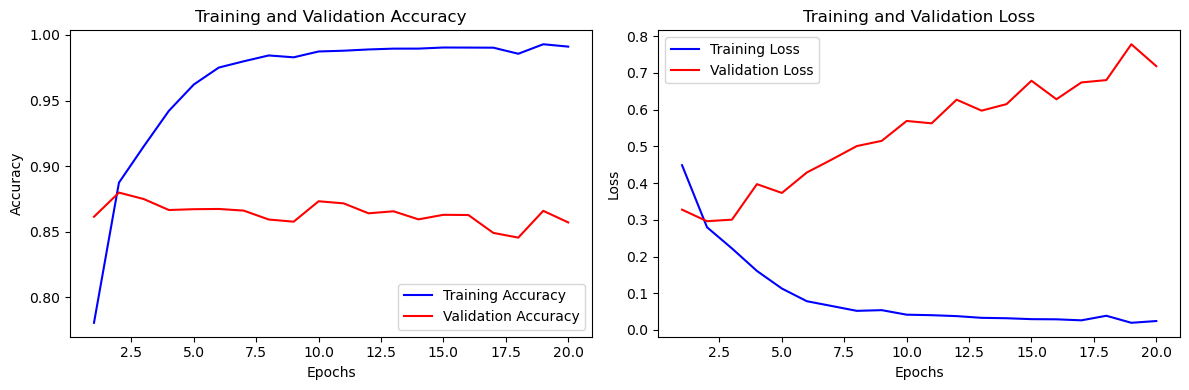

In [91]:
import matplotlib.pyplot as plt

# Extract accuracy and loss values from history
acc = rnns_cv.history['accuracy']
val_acc = rnns_cv.history['val_accuracy']
loss = rnns_cv.history['loss']
val_loss = rnns_cv.history['val_loss']

epochs = range(1, len(acc) + 1)

# Plot Learning Curves
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# Accuracy Plot
axes[0].plot(epochs, acc, 'b', label='Training Accuracy')
axes[0].plot(epochs, val_acc, 'r', label='Validation Accuracy')
axes[0].set_title('Training and Validation Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss Plot
axes[1].plot(epochs, loss, 'b', label='Training Loss')
axes[1].plot(epochs, val_loss, 'r', label='Validation Loss')
axes[1].set_title('Training and Validation Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()